In [1]:
import json
import os
import argparse
from collections import defaultdict

def check_rollout_progress(file_path, K):
    """
    读取实验文件，统计分叉生成进度。
    
    Args:
        file_path (str): 结果 JSON 文件路径
        K (int): 目标 K 值 (总分支数 = 原路径1 + 新增 K-1)
    """
    if not os.path.exists(file_path):
        print(f"❌ Error: File not found at {file_path}")
        return

    print(f"Loading data from: {file_path}")
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"❌ Error loading JSON: {e}")
        return

    # 目标新增数量
    target_new_branches = K - 1
    
    # 统计数据
    total_users = len(data)
    total_branch_points = 0
    completed_branch_points = 0
    incomplete_details = [] # 存储未完成的细节

    print(f"{'='*60}")
    print(f"CHECKING PROGRESS (Target K={K}, Expecting {target_new_branches} new branches per point)")
    print(f"{'='*60}")

    for episode in data:
        user_id = episode.get('user_id', 'Unknown')
        trajectories = episode.get('trajectories', [])
        
        # 1. 找到 Root
        root_traj = next((t for t in trajectories if t['id'] == 'root'), None)
        if not root_traj:
            print(f"⚠️ Warning: User {user_id} has no root trajectory.")
            continue

        # 2. 统计该用户的分叉情况
        # 结构: {turn_number: current_count}
        branch_counts = defaultdict(int)
        
        for t in trajectories:
            if t['id'] == 'root': continue
            
            b_turn = t.get('branch_at_turn')
            if b_turn:
                branch_counts[b_turn] += 1
        
        # 3. 分析该用户的进度
        user_branch_points = len(branch_counts)
        total_branch_points += user_branch_points
        
        user_incomplete = []
        
        for turn, count in branch_counts.items():
            if count >= target_new_branches:
                completed_branch_points += 1
            else:
                user_incomplete.append(f"Turn {turn} ({count}/{target_new_branches})")
        
        if user_incomplete:
            incomplete_details.append({
                "user": user_id,
                "issues": user_incomplete
            })

    # --- 输出统计报告 ---
    print(f"\n📊 Summary Statistics:")
    print(f"  - Total Users Processed:      {total_users}")
    print(f"  - Total Triggered Points:     {total_branch_points}")
    print(f"  - Fully Completed Points:     {completed_branch_points}")
    print(f"  - Incomplete Points:          {total_branch_points - completed_branch_points}")
    
    completion_rate = (completed_branch_points / total_branch_points * 100) if total_branch_points > 0 else 0
    print(f"  - Node Completion Rate:       {completion_rate:.2f}%")

    # 进度条可视化
    bar_len = 30
    filled = int(bar_len * completion_rate / 100)
    bar = '█' * filled + '-' * (bar_len - filled)
    print(f"  - Progress: |{bar}|")

    print(f"\n{'='*60}")
    
    if incomplete_details:
        print(f"🟠 Incomplete Users ({len(incomplete_details)}):")
        print(f"{'User ID':<20} | {'Missing Branches'}")
        print("-" * 50)
        for item in incomplete_details[:20]: # 只显示前20个，防止刷屏
            issues_str = ", ".join(item['issues'])
            print(f"{item['user']:<20} | {issues_str}")
        
        if len(incomplete_details) > 20:
            print(f"... and {len(incomplete_details) - 20} more users.")
    else:
        print(f"✅ All {total_users} users have met the target K={K} for all triggered points!")
        
    print(f"{'='*60}\n")

if __name__ == "__main__":
    K = 5
    Input_file = "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0_sys_Qwen3-8B_think_False_user_gpt-4o/rollout_v1_t_1.0_thinking_False/results_exp_t_1.0.json"
    # Input_file = "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2026-01-13T11-13-31_Order_False_User_False_t_0.0_sys_Qwen3-8B_think_True/rollout_v1_t_1.0_thinking_True/results_exp_t_1.0.json"
    check_rollout_progress(Input_file, K)

Loading data from: /root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0_sys_Qwen3-8B_think_False_user_gpt-4o/rollout_v1_t_1.0_thinking_False/results_exp_t_1.0.json
CHECKING PROGRESS (Target K=5, Expecting 4 new branches per point)

📊 Summary Statistics:
  - Total Users Processed:      18
  - Total Triggered Points:     144
  - Fully Completed Points:     144
  - Incomplete Points:          0
  - Node Completion Rate:       100.00%
  - Progress: |██████████████████████████████|

✅ All 18 users have met the target K=5 for all triggered points!



In [1]:
import json
import os
import random
from collections import defaultdict

# ================= 配置区域 =================
# 基础用户列表 (之前实验已选的 5 个用户)
base_user_data = [
    "persona_36",
    "persona_82",
    "persona_64",
    "persona_16",
    "persona_112",
    "persona_283",
    "persona_280",
    "persona_13",
    "persona_117",
    "persona_288",
]

# 文件路径
BASE_DIR = "/root/EvolvingAgent-master/EvolvingAgentTest_wym"
PERSONA_FILE = os.path.join(BASE_DIR, "user_personas.json")

# 实验结果文件列表 (用于判断用户是成功过还是失败过)
RESULT_FILES = [
    f"{BASE_DIR}/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0_sys_Qwen3-8B_think_False_user_gpt-4o/results_unified_2025-12-22T15-55-18_False_False_t_0.0.json",
    f"{BASE_DIR}/model/Motivation/Experiments/results_unified_2026-01-13T11-13-31_False_False_t_0.0_sys_Qwen3-8B_think_True.json"
]

# 目标覆盖类型 (标准格式：首字母大写)
TARGET_BIG_FIVE = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]
TARGET_DECISION = ["Conceptual", "Analytical", "Directive", "Behavioral"]

# ================= 工具函数 =================

# ================= 工具函数 =================

def load_json(path):
    if not os.path.exists(path):
        print(f"[Warning] File not found: {path}")
        return []
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def normalize_personas(personas):
    """
    将人格和决策风格统一转换为 Title Case (首字母大写)
    """
    normalized = {}
    for uid, profile in personas.items():
        new_profile = profile.copy()
        
        # 处理 Big-Five
        bf = profile.get('Big-Five Personality')
        if bf and isinstance(bf, str):
            new_profile['Big-Five Personality'] = bf.strip().title() # e.g. "openness" -> "Openness"
            
        # 处理 Decision Style
        ds = profile.get('Decision-Making Style')
        if ds and isinstance(ds, str):
            new_profile['Decision-Making Style'] = ds.strip().title() # e.g. "directive" -> "Directive"
            
        normalized[uid] = new_profile
    return normalized

def get_user_strict_status(files):
    """
    严格判定用户状态：
    - Strict Success: 在所有出现的轨迹中均为 True
    - Strict Fail: 在所有出现的轨迹中均为 False
    - Mixed: 有成功也有失败
    """
    # 记录每个用户的所有 outcomes: {uid: [True, True, False]}
    user_history = defaultdict(list)
    
    for file_path in files:
        data = load_json(file_path)
        for episode in data:
            user_id = episode.get('user_id')
            if not user_id: continue
            
            # 判断单次轨迹是否成功
            is_succ = episode.get('success', False)
            
            if not is_succ and 'trajectories' in episode:
                # 检查 root 轨迹
                root = next((t for t in episode['trajectories'] if t['id'] == 'root'), None)
                if root:
                    if root.get('success'): 
                        is_succ = True
                    elif root.get('turns') and root['turns'][-1].get('reward', 0) >= 1.0: 
                        is_succ = True
            
            user_history[user_id].append(is_succ)

    # 生成最终状态标签
    status_map = {}
    for uid, outcomes in user_history.items():
        if not outcomes:
            status_map[uid] = "Unknown"
        elif all(outcomes):
            status_map[uid] = "Strict Success"
        elif not any(outcomes):
            status_map[uid] = "Strict Fail"
        else:
            status_map[uid] = "Mixed"
            
    return status_map

# ================= 主逻辑 =================

def main():
    # 1. 加载数据并清洗
    print("Loading and normalizing data...")
    raw_personas = load_json(PERSONA_FILE)
    personas = normalize_personas(raw_personas) # 关键修正1：统一大小写
    
    # 2. 获取严格状态
    user_status = get_user_strict_status(RESULT_FILES) # 关键修正2：严格一致性判定
    
    # 3. 构建候选池 (只包含 Strict 样本)
    # pool[Category][Value]['Strict Success'] = [user_id...]
    pool = {
        'Big-Five Personality': defaultdict(lambda: {'Strict Success': [], 'Strict Fail': []}),
        'Decision-Making Style': defaultdict(lambda: {'Strict Success': [], 'Strict Fail': []})
    }
    
    for uid, status in user_status.items():
        if uid not in personas: continue
        # 如果是 Mixed 或 Unknown，不放入候选池（不用于补全）
        if status not in ['Strict Success', 'Strict Fail']:
            continue
            
        p = personas[uid]
        bf = p.get('Big-Five Personality')
        dm = p.get('Decision-Making Style')
        
        if bf in TARGET_BIG_FIVE:
            pool['Big-Five Personality'][bf][status].append(uid)
        if dm in TARGET_DECISION:
            pool['Decision-Making Style'][dm][status].append(uid)

    # 4. 初始化结果集
    final_users = set(base_user_data)
    
    # 5. 检查覆盖率并补全
    def check_and_fill(category_name, target_values):
        print(f"\n--- Checking {category_name} ---")
        for val in target_values:
            # 对于每个类型，我们需要 1个 Strict Success 和 1个 Strict Fail
            for target_status in ['Strict Success', 'Strict Fail']:
                
                # 检查当前 final_users 是否已覆盖
                covered = False
                for uid in final_users:
                    u_val = personas.get(uid, {}).get(category_name)
                    u_stat = user_status.get(uid, "Unknown")
                    
                    # 只要当前集合里的用户满足类型且状态一致即可
                    # (注意：Mixed 状态的用户不能用来充当 Success 或 Fail 的指标)
                    if u_val == val and u_stat == target_status:
                        covered = True
                        break
                
                if covered:
                    print(f"  [OK] {val:<15} | {target_status} (Covered)")
                else:
                    # 未覆盖，从池子选
                    candidates = pool[category_name][val][target_status]
                    # 排除已选
                    candidates = [u for u in candidates if u not in final_users]
                    
                    if candidates:
                        new_user = random.choice(candidates)
                        final_users.add(new_user)
                        print(f"  [ADDED] {val:<12} | {target_status} -> Added {new_user}")
                    else:
                        # 如果没有 Strict 的候选人，尝试放宽要求？
                        # 根据题目要求“保证”，这里只能报 Warning
                        print(f"  [WARNING] {val:<12} | {target_status} -> No STRICT candidates found!")

    check_and_fill('Big-Five Personality', TARGET_BIG_FIVE)
    check_and_fill('Decision-Making Style', TARGET_DECISION)

    # 6. 输出最终表格
    print("\n" + "="*95)
    print(f"{'User ID':<15} | {'Big-Five':<20} | {'Decision Style':<15} | {'Status (Strict)':<15}")
    print("-" * 95)
    
    sorted_users = sorted(list(final_users))
    # Base users 置顶
    sorted_users = sorted(sorted_users, key=lambda x: 0 if x in base_user_data else 1)

    for uid in sorted_users:
        p = personas.get(uid, {})
        status = user_status.get(uid, "N/A")
        
        bf = p.get('Big-Five Personality', 'N/A')
        dm = p.get('Decision-Making Style', 'N/A')
        
        mark = "*" if uid in base_user_data else " "
        
        # 颜色标记（可选，终端显示用）
        status_str = status
        if status == "Strict Success": status_str = "\033[92mStrict Success\033[0m"
        elif status == "Strict Fail": status_str = "\033[91mStrict Fail\033[0m"
        elif status == "Mixed": status_str = "\033[93mMixed\033[0m"
        
        print(f"{mark}{uid:<14} | {bf:<20} | {dm:<15} | {status_str:<15}")
    
    print("-" * 95)
    print(f"Total Users: {len(final_users)} (Base: {len(base_user_data)}, Added: {len(final_users)-len(base_user_data)})")
    
    print("\n[Copy List]:")
    print(json.dumps(list(final_users)))

if __name__ == "__main__":
    main()

Loading and normalizing data...

--- Checking Big-Five Personality ---
  [ADDED] Openness     | Strict Success -> Added persona_80
  [OK] Openness        | Strict Fail (Covered)
  [WARNING] Conscientiousness | Strict Success -> No STRICT candidates found!
  [OK] Conscientiousness | Strict Fail (Covered)
  [ADDED] Extraversion | Strict Success -> Added persona_58
  [ADDED] Extraversion | Strict Fail -> Added persona_296
  [ADDED] Agreeableness | Strict Success -> Added persona_72
  [OK] Agreeableness   | Strict Fail (Covered)
  [ADDED] Neuroticism  | Strict Success -> Added persona_113
  [ADDED] Neuroticism  | Strict Fail -> Added persona_45

--- Checking Decision-Making Style ---
  [ADDED] Conceptual   | Strict Success -> Added persona_48
  [OK] Conceptual      | Strict Fail (Covered)
  [OK] Analytical      | Strict Success (Covered)
  [ADDED] Analytical   | Strict Fail -> Added persona_14
  [OK] Directive       | Strict Success (Covered)
  [OK] Directive       | Strict Fail (Covered)


In [1]:
# 提取应该有的用户

import json
import random

input_file = "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0_sys_Qwen3-8B_think_False_user_gpt-4o/results_unified_2025-12-22T15-55-18_False_False_t_0.0.json"
output_file = "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0_sys_Qwen3-8B_think_False_user_gpt-4o/results_unified_2025-12-22T15-55-18_False_False_t_0.0_Sample_10.json"

def sample_episodes(episodes, n):
    # random_seed = 42
    random_seed = 24
    random.seed(random_seed)
    if n >= len(episodes):
        return episodes
    else:
        e1 = random.sample(episodes, n)
    
    radom_seed = 42
    random.seed(radom_seed)
    if n >= len(episodes):
        return episodes
    else:
        e2 = random.sample(episodes, n)

    target_episodes = e1 + e2
    return target_episodes

with open(input_file, 'r') as f:
    data = json.load(f)
    data = sample_episodes(data,5)

for episode in data:
    print(f"Episode ID: {episode['user_id']}, success: {episode['success']}")

with open(output_file, 'w') as f:
    json.dump(data, f, indent=4)

Episode ID: persona_36, success: False
Episode ID: persona_82, success: True
Episode ID: persona_64, success: False
Episode ID: persona_16, success: False
Episode ID: persona_112, success: False
Episode ID: persona_283, success: False
Episode ID: persona_280, success: False
Episode ID: persona_13, success: False
Episode ID: persona_117, success: False
Episode ID: persona_288, success: False


# 分析实验

result_e0_v1.json: 不使用策略集，不开启 thinking 7/50

result_e0_v2.json: 不使用策略集，开启 thinkning  6/50

result_v4.json: 完整的策略集；9/50

result_v5.json: 删除了 foot-in-the-door 策略 2/50

result_v6.json: 删除了 foot-in-the-door 策略+生成新策略+策略轨迹+（给了示例） 0/50

result_v9.json: 删除了 foot-in-the-door 策略+生成新策略+策略轨迹+（没有给示例）12/50

model/Motivation/Experiments/results_unified_2025-12-15T23-51-06.json: thinking模式， 用 Qwen2.5-72B来当做用户，使用推理-决策-生成回复提示词，14/50

/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-18T10-16-26_False_False.json：thinking 模式，用 gpt-4o 来做用户，使用推理-决策-生成回复提示词，17/50

/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-19T23-19-19_False_True.json：不开启thinking 模式，用 Qwen2.5-72B 来做用户，使用推理-决策-生成回复提示词，14/50

/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-19T23-20-14_False_False.json：不开启thinking 模式，用 gpt-4o 来做用户，使用推理-决策-生成回复提示词，9/50

In [1]:
import json, os, sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from io import StringIO # 用于处理多张表到同一个文

# --- 1. 加载数据 ---
def load_data(results_filepath='results.jsonl'):
    """加载所有用户的实验结果数据"""
    data = []
    with open(results_filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

def get_persona_info(persona_id, persona_data):
    """根据 user_id 获取人格信息"""
    # 假设 persona_data 是从 persona.json 加载的字典
    return persona_data.get(persona_id, {})

## 分析成功和失败的情况

In [2]:
"""
统计成功率情况：
1. 成功的 personal_id 列表
2. 各个人格上的统计情况（以柱状图展示，注明失败和成功的数量）
"""

def verify_correct_data(results_list, expected_user_count=50):
    """
    校验每个结果文件是否包含预期的用户数量，并检查用户 ID 集合是否一致。

    Args:
        results_list (list): 包含所有 JSON 文件路径的列表。
        expected_user_count (int): 期望的每个文件中的用户数量。
    """
    
    print("--- 启动数据一致性校验 ---")
    
    user_sets = {}
    
    for file_path in results_list:
        data = load_data(file_path) # 使用您提供的 load_data
        
        if data is None:
            continue
            
        file_name = os.path.basename(file_path)
        
        # 1. 提取当前文件的用户 ID 集合
        current_user_ids = set()
        for user_record in data:
            # 假设每个用户的记录结构为 {"infos": {"user_id": "..."}}
            try:
                user_id = user_record['infos']['user_id']
                current_user_ids.add(user_id)
            except KeyError:
                print(f"Warning: {file_name} 记录中缺少 'user_id' 键。跳过该记录。")
                continue
        
        # 2. 校验文件完整性 (用户数量)
        actual_count = len(current_user_ids)
        if actual_count != expected_user_count:
            print(f"[{file_name}] 文件完整性 FAIL: 预期用户数 {expected_user_count}，实际用户数 {actual_count}")
        else:
            print(f"[{file_name}] 文件完整性 PASS: 包含 {actual_count} 个用户。")
            
        user_sets[file_name] = current_user_ids
        
    # 3. 校验用户集合一致性 (如果文件多于一个)
    if len(user_sets) < 2:
        print("\n仅有一个文件或加载失败，无法进行集合一致性对比。")
        return

    print("\n--- 校验用户 ID 集合是否一致 ---")
    
    # 提取第一个文件的用户集合作为基准
    first_file_name = list(user_sets.keys())[0]
    base_set = user_sets[first_file_name]
    is_consistent = True
    
    for file_name, current_set in user_sets.items():
        if file_name == first_file_name:
            continue
        
        # 检查是否完全相等
        if base_set != current_set:
            is_consistent = False
            
            # 详细报告差异
            missing_in_current = base_set - current_set
            extra_in_current = current_set - base_set
            
            print(f"一致性 FAIL: {file_name} 与 {first_file_name} 的用户集合不一致。")
            if missing_in_current:
                print(f"  -> {file_name} 缺失用户: {missing_in_current}")
            if extra_in_current:
                print(f"  -> {file_name} 多余用户: {extra_in_current}")
        
    if is_consistent:
        print("一致性 PASS: 所有文件的用户 ID 集合完全相同。")

def aggregate_dialogue_outcomes(results_list, persona_data):
    """
    加载多个实验结果文件，并聚合每个对话的最终结果和人格信息。
    
    Args:
        results_list (list): 包含所有 JSON 文件路径的列表。
        persona_data (dict): 包含所有用户人格信息的字典。
        
    Returns:
        pd.DataFrame: 包含 'user_id', 'success', 'Big-Five Personality', 'Decision-Making Style' 的 DataFrame。
    """
    all_dialogues = []
    
    # 使用 set 确保每个 user_id 在每个文件中只被处理一次 (防止重复)
    processed_dialogues = set() 
    
    for file_path in results_list:
        try:
            data = load_data(file_path)
            
            for user_record in data:
                user_id = user_record['infos']['user_id']
                
                # 检查该对话是否已处理 (避免跨文件重复计数)
                if (user_id, file_path) in processed_dialogues:
                    continue
                
                # 提取结果
                is_success = user_record['infos']['success']
                
                # 获取人格信息
                persona = get_persona_info(user_id, persona_data)
                
                all_dialogues.append({
                    'user_id': user_id,
                    'file_source': file_path,
                    'success': is_success,
                    'Big-Five Personality': persona.get('Big-Five Personality').lower(),
                    'Decision-Making Style': persona.get('Decision-Making Style').lower()
                })
                processed_dialogues.add((user_id, file_path))
                
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue
            
    # 将成功的布尔值转换为字符串标签
    df = pd.DataFrame(all_dialogues)
    df['Outcome'] = df['success'].apply(lambda x: 'Success' if x else 'Failure')
    
    return df

def sort_by_persona_number(persona_id):
    # 提取下划线后的数字部分
    try:
        return int(persona_id.split('_')[1])
    except:
        return 999999 # 确保无法解析的放在最后

In [4]:
def generate_persona_success_rate_table(results_list, persona_data):
    """
    统计每个实验文件在不同人格下的成功和失败数量及成功率。
    """
    
    all_results = []
    # --- 1. 迭代加载并处理数据 ---
    for file_path in results_list:
        # 假设 load_data 和 get_persona_info 能够正常运行
        data = load_data(file_path) 
        if data is None:
            continue
            
        # 简化文件名提取
        file_name = os.path.basename(file_path)
        
        # 存储当前文件的对话结果
        file_dialogues = []
        for user_record in data:
            if 'infos' not in user_record:
                user_id = user_record['user_id']
                is_success = user_record['success']
            else:
                user_id = user_record['infos']['user_id']
                is_success = user_record['infos']['success']
            
            persona = get_persona_info(user_id, persona_data)
            
            file_dialogues.append({
                'file_source': file_name,
                'user_id': user_id,
                'success': is_success,
                # 确保人格名称统一为小写，以便分组
                'Big-Five Personality': persona.get('Big-Five Personality', 'Unknown').lower(),
                'Decision-Making Style': persona.get('Decision-Making Style', 'Unknown').lower()
            })
        all_results.extend(file_dialogues)
    
    df = pd.DataFrame(all_results)
    if df.empty:
        print("没有可用的实验数据。")
        return
        
    df['Outcome'] = df['success'].apply(lambda x: 'Success' if x else 'Failure')

    # --- 1. 按实验文件和人格类型进行聚合统计 ---
    
    def aggregate_and_format(df_input, persona_type, title):
        # 聚合成功、失败数量
        agg_df = df_input.groupby(['file_source', persona_type, 'Outcome']).size().unstack(fill_value=0)
        
        if 'Success' not in agg_df.columns:
            agg_df['Success'] = 0
        if 'Failure' not in agg_df.columns:
            agg_df['Failure'] = 0
            
        # 计算总数 (Total Count)
        agg_df['Total'] = agg_df['Success'] + agg_df['Failure']
        agg_df['SR (%)'] = (agg_df['Success'] / agg_df['Total'] * 100)

        # *** 关键修改：提取所需的列，包含 Total ***
        result_cols = ['Total', 'Success', 'SR (%)']
        
        agg_df = agg_df.reset_index(level='file_source')
        
        # 重新构建列结构
        final_table = agg_df[['file_source'] + result_cols].set_index('file_source', append=True)
        final_table = final_table.unstack(level='file_source')
        
        # 清理列名 (Total (file_name), Success (file_name), SR (%) (file_name))
        final_table.columns = [f"{col[0]} ({col[1]})" for col in final_table.columns]
        
        print(f"\n--- {title} 性能对比 (包含对话数量) ---")
        print(final_table.to_markdown(floatfmt=".1f"))
        
        return final_table

    # 运行并打印 Big-Five 人格统计
    big_five_table = aggregate_and_format(df, 'Big-Five Personality', "Big-Five Personality")
    
    # 运行并打印 Decision-Making Style 统计
    dm_style_table = aggregate_and_format(df, 'Decision-Making Style', "Decision-Making Style")
    
    return big_five_table, dm_style_table, df # 返回原始df供下一步分析

# ----------------------------------------------------------------------
# 新增功能：输出每个文件成功的用户 ID 列表
# ----------------------------------------------------------------------
def analyze_successful_users_by_file(df):
    """
    统计并打印每个文件来源中成功的 user_id 列表。
    """
    print("\n--- 成功的用户 ID 列表 (按实验文件来源) ---")
    
    success_df = df[df['success'] == True].copy()
    
    # 确保只计数独立对话 (user_id x file_source)
    success_groups = success_df.groupby('file_source')['user_id'].apply(lambda x: list(set(x))).reset_index()
    success_groups['user_id'] = success_groups['user_id'].apply(
        lambda id_list: sorted(id_list, key=sort_by_persona_number)
    )
    
    success_groups['Success Count'] = success_groups['user_id'].apply(len)
    
    # 格式化输出
    success_groups = success_groups.rename(columns={'file_source': '实验文件', 'user_id': '成功用户ID列表'})
    
    # 打印表格
    print(success_groups[['实验文件', 'Success Count', '成功用户ID列表']].to_markdown(index=False))

    # 打印总计成功的去重用户数量
    unique_successful_users = success_df['user_id'].nunique()
    print(f"\n跨所有文件总计成功去重的用户数量: {unique_successful_users}")

In [5]:
results_list = [
    # "/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_e0_v1.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_e0_v2.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v4.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v5.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v6.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v9.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-18T22-41-14_False_False.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-18T23-43-55_False_True.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-19T23-19-19_False_True.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-19T23-20-14_False_False.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-22T12-47-43_False_False_t_0.0.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-22T15-52-33_False_True_t_0.0.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-22T15-55-18_False_False_t_0.0.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-24T13-56-20_False_True_t_0.0.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0/results_unified_2025-12-22T15-55-18_False_False_t_0.0.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2026-01-12T22-12-57_False_False_t_0.0_sys_gpt-4o-mini.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-22T15-52-33_False_True_t_0.0.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-24T13-56-20_False_True_t_0.0.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2026-01-13T11-13-31_False_False_t_0.0_sys_Qwen3-8B_think_True.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2026-01-14T14-56-23_False_False_t_0.0_sys_qwen2.5-7B-Instruct_think_False.json",
    # "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2026-01-14T19-31-20_True_False_t_0.0_sys_Qwen3-8B_think_False.json"
    "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0_sys_Qwen3-8B_think_False_user_gpt-4o/results_unified_2025-12-22T15-55-18_False_False_t_0.0.json",
    "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2026-01-13T11-13-31_False_False_t_0.0_sys_Qwen3-8B_think_True.json"
]
# verify_correct_data(results_list=results_list, expected_user_count=50)

# 假设：需要加载实际的 persona_data
persona_data = load_data(r"/root/EvolvingAgent-master/EvolvingAgentTest/user_personas.json")

big_five_results, dm_style_results, df_outcomes = generate_persona_success_rate_table(results_list=results_list, persona_data=persona_data)

# 2. 分析成功的用户列表
analyze_successful_users_by_file(df_outcomes)

# # 如果需要保存为 CSV：
result_dir = "/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation"
big_five_results.to_csv("big_five_performance_summary.csv")
dm_style_results.to_csv("dm_style_performance_summary.csv")


--- Big-Five Personality 性能对比 (包含对话数量) ---
| Big-Five Personality   |   Total (results_unified_2025-12-22T15-55-18_False_False_t_0.0.json) |   Total (results_unified_2026-01-13T11-13-31_False_False_t_0.0_sys_Qwen3-8B_think_True.json) |   Success (results_unified_2025-12-22T15-55-18_False_False_t_0.0.json) |   Success (results_unified_2026-01-13T11-13-31_False_False_t_0.0_sys_Qwen3-8B_think_True.json) |   SR (%) (results_unified_2025-12-22T15-55-18_False_False_t_0.0.json) |   SR (%) (results_unified_2026-01-13T11-13-31_False_False_t_0.0_sys_Qwen3-8B_think_True.json) |
|:-----------------------|---------------------------------------------------------------------:|---------------------------------------------------------------------------------------------:|-----------------------------------------------------------------------:|-----------------------------------------------------------------------------------------------:|---------------------------------------------------------------

我的想法：
1. 先评估熵值的分布（在多轮对话上的分布，在不同人格上对话的分布，在成功或失败上的对话分布） <- 首先清楚分布
2. 是否和策略划分的阶段、策略慢思考和快思考存在关系？

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

def analyze_high_entropy_strategies(df, entropy_threshold=0.225):
    """
    分析策略熵高于阈值的策略的类型、时间分布和成功率。
    
    Args:
        df (pd.DataFrame): 包含所有策略回合信息的DataFrame。
        entropy_threshold (float): 高熵策略的筛选阈值 (70% Quantile)。
    """
    
    # 筛选高熵策略
    high_entropy_df = df[df['entropy'] > entropy_threshold].copy()
    
    if high_entropy_df.empty:
        print(f"没有策略熵高于 {entropy_threshold} 的数据。")
        return

    print(f"\n--- 高熵策略分析 (Entropy > {entropy_threshold:.3f}) ---")
    
    # ===================================================================
    # PART A: 策略类型分布统计
    # ===================================================================
    
    strategy_counts = high_entropy_df.groupby('strategy')['success'].agg(
        total_count='count',
        success_count=lambda x: (x == True).sum(),
        failure_count=lambda x: (x == False).sum()
    ).reset_index()

    strategy_counts['Success Rate (%)'] = (strategy_counts['success_count'] / strategy_counts['total_count']) * 100
    
    strategy_counts['Failure Count (%)'] = 100 - strategy_counts['Success Rate (%)']
    
    # 整理表格列
    strategy_counts = strategy_counts.rename(columns={'strategy': '策略类型', 'total_count': '总出现次数', 
                                                     'success_count': '成功对话中出现次数 (True)', 
                                                     'failure_count': '失败对话中出现次数 (False)'})
    
    strategy_counts['成功百分比'] = strategy_counts.apply(
        lambda row: f"{row['成功对话中出现次数 (True)']} ({row['Success Rate (%)']:.0f}%)", axis=1
    )
    strategy_counts['失败百分比'] = strategy_counts.apply(
        lambda row: f"{row['失败对话中出现次数 (False)']} ({row['Failure Count (%)']:.0f}%)", axis=1
    )
    
    # 最终输出表格
    output_table_A = strategy_counts[['策略类型', '总出现次数', '成功百分比', '失败百分比']].sort_values(by='总出现次数', ascending=False)
    
    print("\n[表 A: 高熵策略类型分布 (策略功能归类需要手动添加)]")
    print(output_table_A.to_markdown(index=False))

    # ===================================================================
    # PART B: 时间（阶段）分布统计
    # ===================================================================
    
    # 按阶段分组
    stage_counts = high_entropy_df.groupby('Dialogue_Stage')['success'].agg(
        total_count='count',
        success_count=lambda x: (x == True).sum(),
        failure_count=lambda x: (x == False).sum()
    ).reset_index()

    stage_counts['Success Rate (%)'] = (stage_counts['success_count'] / stage_counts['total_count']) * 100
    stage_counts['Failure Count (%)'] = 100 - stage_counts['Success Rate (%)']

    # 确保阶段顺序
    stage_order = ['Early Stage (1-3)', 'Mid Stage (4-6)', 'Late Stage (7-10)']
    stage_counts['Dialogue_Stage'] = pd.Categorical(stage_counts['Dialogue_Stage'], categories=stage_order, ordered=True)
    stage_counts = stage_counts.sort_values('Dialogue_Stage')

    # 整理输出表格
    stage_counts = stage_counts.rename(columns={'Dialogue_Stage': '阶段', 'total_count': '高熵策略总数'})
    stage_counts['成功百分比'] = stage_counts.apply(
        lambda row: f"{row['success_count']} ({row['Success Rate (%)']:.0f}%)", axis=1
    )
    stage_counts['失败百分比'] = stage_counts.apply(
        lambda row: f"{row['failure_count']} ({row['Failure Count (%)']:.0f}%)", axis=1
    )

    output_table_B = stage_counts[['阶段', '高熵策略总数', '成功百分比', '失败百分比']]
    
    print("\n[表 B: 高熵策略时间（阶段）分布]")
    print(output_table_B.to_markdown(index=False))
    
    return high_entropy_df # 返回高熵策略子集，以便进行进一步分析



if __name__ == "__main__":
    result_path = r"/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_e0_v2.json"
    with open(result_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print(len(data))
    persona_path = r"/root/EvolvingAgent-master/EvolvingAgentTest/user_personas.json"

    num_fast_strategy = 0
    num_slow_strategy = 0
    num_success = 0
    for idx, item in enumerate(data):
        persona_id = item['infos']['user_id']
        success_result = item['infos']['success']
        if success_result:
            num_success+=1
            # print(item['infos']['turns'])
        trajectory = item["trajectory"]
        for traj in trajectory:
            if "strategy_entropy" in traj and  traj["strategy_entropy"]>0.225:
                print(f"{persona_id}: {success_result}, {traj['strategy']} - {traj['round']}")
        
        if 'judge_result' in item:
            judge_result = item['judge_result']
            strategy_judge_result = judge_result['strategy_judge_result']
            for res_idx, res in enumerate(strategy_judge_result):
                if res['thinking_type'].lower() == "fast":
                    num_fast_strategy += 1
                    if res_idx != 0:
                        pass
                        # print(item['infos']['user_id'])
                else:
                    num_slow_strategy += 1
    print(num_success)
    print(num_slow_strategy)
    print(num_fast_strategy)

6
0
0


## 熵值的分布

### 全局熵分布
    # A1：带分位线的全局熵分布
    # plot_global_entropy_distribution_with_quantiles(df)
    plot_entropy_percentiles_histogram(df)
    
    # A2：熵值的区间分布
    plot_entropy_bins_barchart(df, num_bins=10)

    # A3：成功 vs. 失败的分阶段熵分布对比
    plot_staged_entropy_comparison(df)


--- 策略熵的关键百分位点 ---
10% 的决策点熵值低于或等于: 0.0000
20% 的决策点熵值低于或等于: 0.0002
30% 的决策点熵值低于或等于: 0.0037
40% 的决策点熵值低于或等于: 0.0079
50% 的决策点熵值低于或等于: 0.0319
60% 的决策点熵值低于或等于: 0.1959
70% 的决策点熵值低于或等于: 0.4863
80% 的决策点熵值低于或等于: 0.7008
90% 的决策点熵值低于或等于: 1.0289


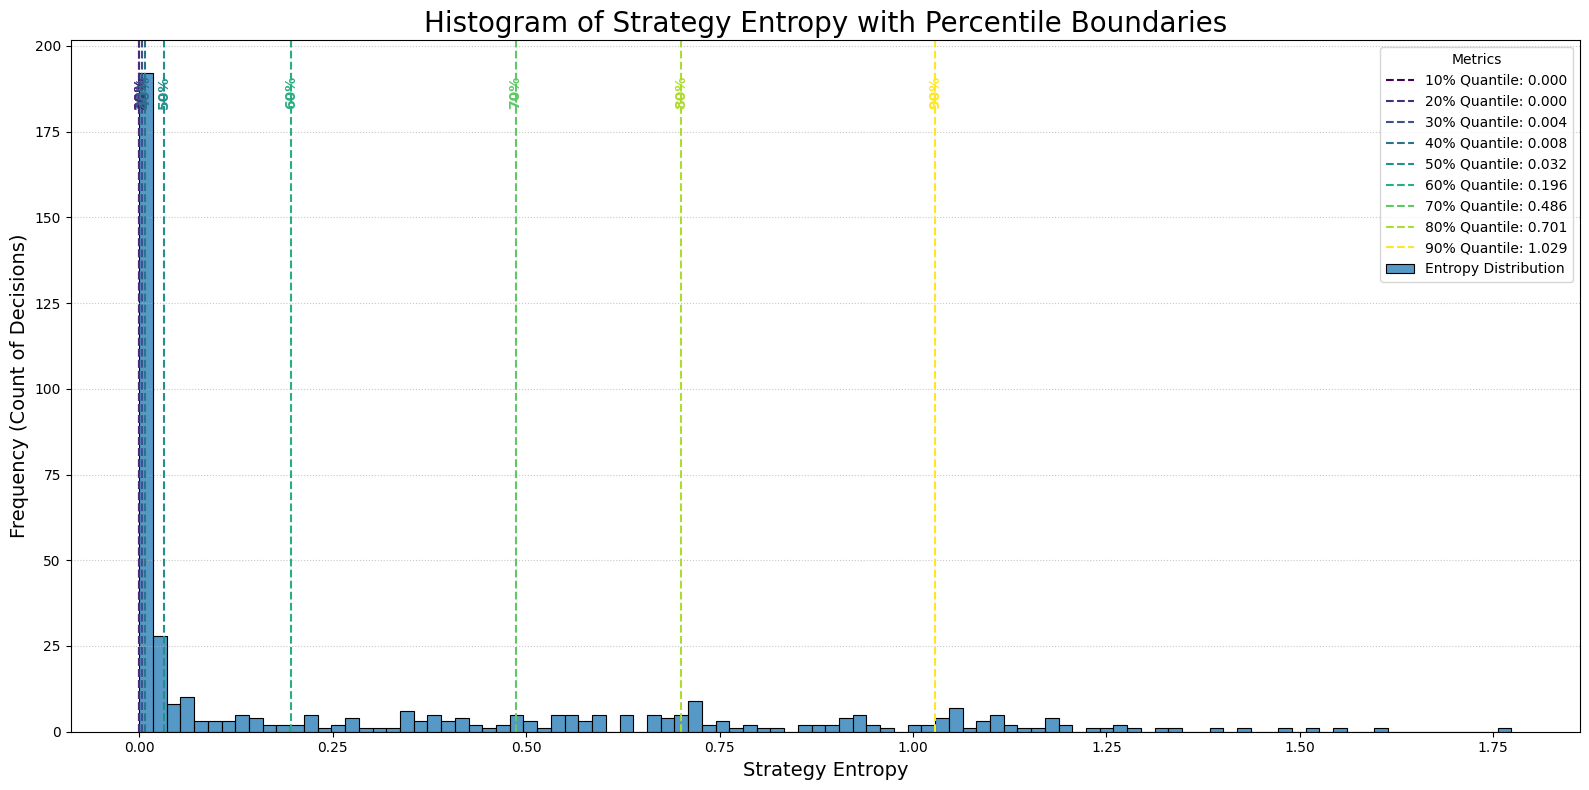

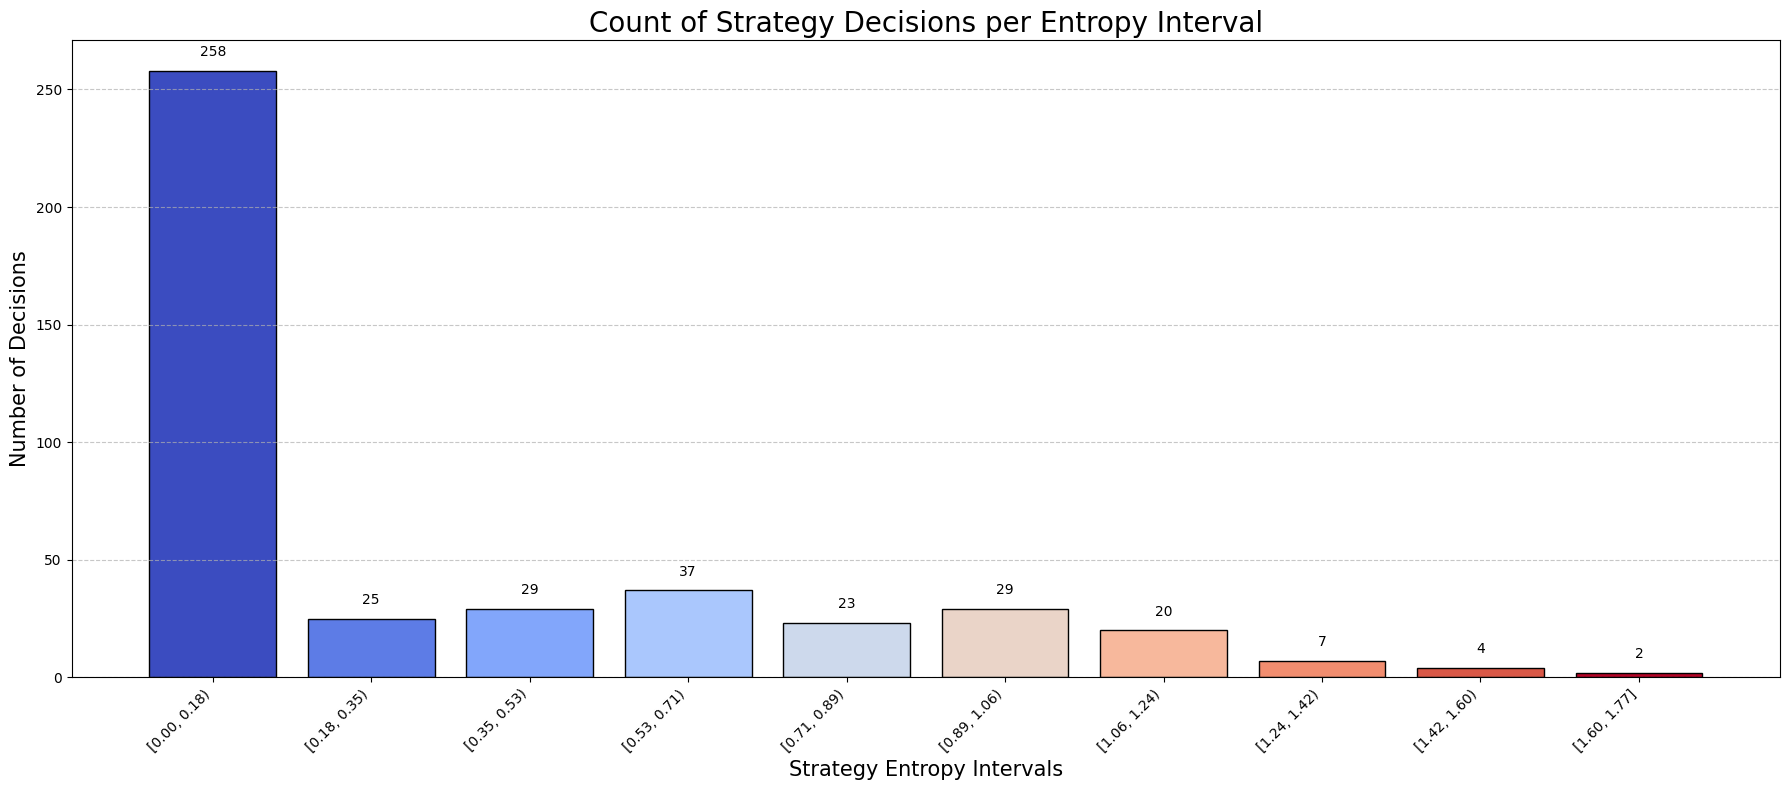

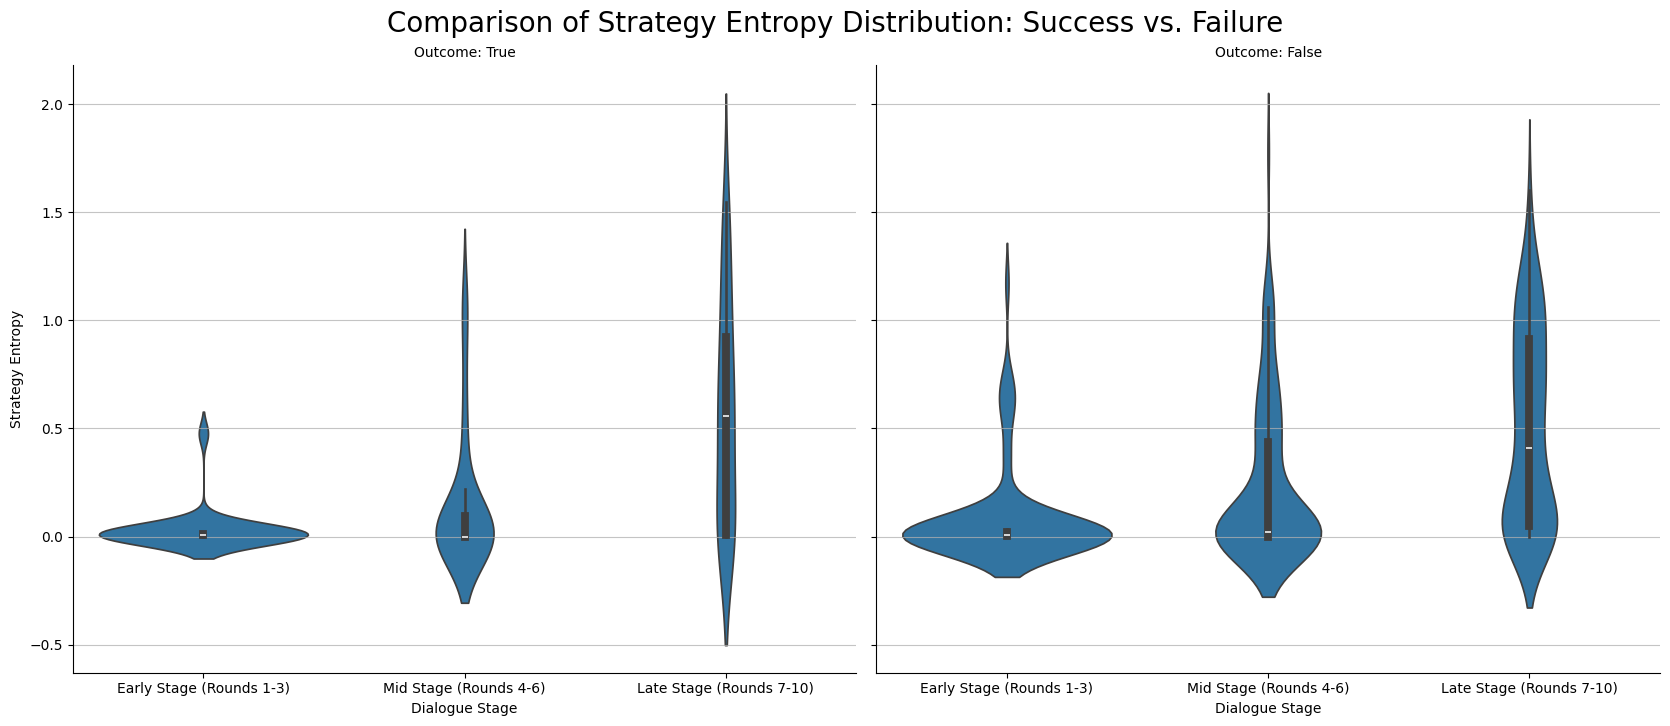

In [ ]:
# --- 2. 解析并构建 DataFrame ---
def build_dataframe(all_results):
    """
    将原始数据解析为结构化的 Pandas DataFrame，便于分析。
    我们只关心系统 (Persuader) 的策略选择。
    """
    records = []
    for result in all_results:
        user_id = result['infos']['user_id']
        success = result['infos']['success']
        
        # 筛选出 Persuader 的发言
        persuader_turns = [turn for turn in result['trajectory'] if turn['role'] == 'Persuader']
        
        for turn in persuader_turns:
            # 忽略第一轮固定的 greeting
            if 'strategy_entropy' in turn:
                records.append({
                    'user_id': user_id,
                    'success': success,
                    'round': turn['round'],
                    'strategy': turn['strategy'],
                    'entropy': turn['strategy_entropy']
                })
    
    return pd.DataFrame(records)

# --- 3. 定义对话阶段 ---
def assign_dialogue_stage(round_number):
    """根据对话轮次，划分前、中、后三个阶段"""
    if 1 <= round_number <= 3:
        return 'Early Stage (Rounds 1-3)'
    elif 4 <= round_number <= 6:
        return 'Mid Stage (Rounds 4-6)'
    else: # 7 <= round_number <= 10
        return 'Late Stage (Rounds 7-10)'

def plot_global_entropy_distribution_with_quantiles(df):
    """
    绘制全局策略熵值的分布图，并增加 20% 和 80% 分位线。
    """
    plt.figure(figsize=(14, 7))
    sns.histplot(df['entropy'], kde=True, bins=50, stat="density") # 使用密度而不是频率
    
    # 计算并绘制分位线
    q20 = df['entropy'].quantile(0.20)
    q80 = df['entropy'].quantile(0.80)
    
    plt.axvline(q20, color='g', linestyle=':', linewidth=2, label=f'20th Percentile (q=0.20): {q20:.4f}')
    plt.axvline(q80, color='r', linestyle='--', linewidth=2, label=f'80th Percentile (q=0.80): {q80:.4f}')
    
    plt.title('Global Distribution of Strategy Entropy with 20/80 Quantiles', fontsize=18)
    plt.xlabel('Strategy Entropy', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    
    print(f"\n--- 全局熵值分位点 ---")
    print(f"20% 的决策点熵值低于: {q20:.4f} (可以视为'快思考'区域)")
    print(f"80% 的决策点熵值低于: {q80:.4f} (熵最高的20%决策点始于此)")
    
    plt.show()

def plot_entropy_percentiles_histogram(df):
    """
    计算并绘制策略熵的直方图，同时在图上标记出关键的百分位点。
    """
    if df.empty or df['entropy'].isnull().all():
        print("数据为空或熵值全部缺失，无法绘图。")
        return

    # --- 1. 计算百分位点 ---
    percentiles = np.arange(0.1, 1.0, 0.1) # [0.1, 0.2, ..., 0.9]
    quantile_values = df['entropy'].quantile(percentiles)
    
    print("\n--- 策略熵的关键百分位点 ---")
    for p, q_val in quantile_values.items():
        print(f"{int(p*100)}% 的决策点熵值低于或等于: {q_val:.4f}")

    # --- 2. 绘制直方图和百分位线 ---
    plt.figure(figsize=(16, 8))
    
    # 绘制直方图
    sns.histplot(df['entropy'], bins=100, kde=False, stat="count", label='Entropy Distribution')
    
    # 获取当前 y 轴的最大值，用于设定虚线的高度
    y_max = plt.gca().get_ylim()[1]
    
    # 绘制并标记每一个百分位线
    colors = plt.cm.viridis(np.linspace(0, 1, len(quantile_values)))
    for (p, q_val), color in zip(quantile_values.items(), colors):
        percent = int(p * 100)
        plt.axvline(q_val, color=color, linestyle='--', linewidth=1.5, 
                    label=f'{percent}% Quantile: {q_val:.3f}')
        # 在线上方标记百分比
        plt.text(q_val, y_max * 0.9, f'{percent}%', rotation=90, 
                 verticalalignment='bottom', horizontalalignment='center',
                 color=color, fontsize=10, fontweight='bold')
    
    # --- 3. 美化图表 ---
    plt.title('Histogram of Strategy Entropy with Percentile Boundaries', fontsize=20)
    plt.xlabel('Strategy Entropy', fontsize=14)
    plt.ylabel('Frequency (Count of Decisions)', fontsize=14)
    plt.legend(title='Metrics')
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout() # 调整布局防止标签重叠
    
    plt.show()

def plot_staged_entropy_comparison(df):
    """
    按“成功”和“失败”两种情况，分别绘制分阶段的熵分布小提琴图。
    """
    df['stage'] = df['round'].apply(assign_dialogue_stage)
    
    # 使用 FacetGrid 创建一个 1x2 的子图网格
    g = sns.FacetGrid(df, col="success", height=7, aspect=1.2, 
                      col_order=[True, False], # 指定顺序，成功在左，失败在右
                      sharey=True) # 保证 Y 轴尺度相同，便于比较
    
    # 在每个子图上绘制小提琴图
    g.map(sns.violinplot, "stage", "entropy",
          order=['Early Stage (Rounds 1-3)', 'Mid Stage (Rounds 4-6)', 'Late Stage (Rounds 7-10)'])
    
    # 设置标题和标签
    g.fig.suptitle('Comparison of Strategy Entropy Distribution: Success vs. Failure', fontsize=20, y=1.03)
    g.set_axis_labels("Dialogue Stage", "Strategy Entropy")
    g.set_titles("Outcome: {col_name}") # {col_name} 会被自动替换为 True/False
    
    # 为每个子图添加网格线
    for ax in g.axes.flat:
        ax.grid(axis='y', alpha=0.75)
        
    plt.show()

def plot_entropy_bins_barchart(df, num_bins=10):
    """
    将熵值划分为 n 个区间，并用柱状图统计每个区间的数量。
    """
    # 1. 确定熵值的最大值和最小值，以定义区间边界
    min_entropy = df['entropy'].min()
    max_entropy = df['entropy'].max()
    
    # 2. 使用 numpy.linspace 创建 n+1 个等距的边界点
    bins = np.linspace(min_entropy, max_entropy, num_bins + 1)
    
    # 3. 使用 pandas.cut 将每个熵值分配到对应的区间中
    #    - labels=False 会返回区间的整数索引 (0, 1, 2, ...)
    df['entropy_bin'] = pd.cut(df['entropy'], bins=bins, labels=False, include_lowest=True)
    
    # 4. 创建可读的区间标签，用于图表显示
    #    例如: "[0.00, 0.17)", "[0.17, 0.34)", ...
    bin_labels = [f'[{bins[i]:.2f}, {bins[i+1]:.2f})' for i in range(num_bins)]
    # 最后一个区间是闭合的
    bin_labels[-1] = f'[{bins[-2]:.2f}, {bins[-1]:.2f}]'
    
    # 5. 统计每个区间的数量
    bin_counts = df['entropy_bin'].value_counts().sort_index()
    
    # --- 6. 开始绘图 ---
    plt.figure(figsize=(18, 8))
    
    # 创建一个颜色映射，从蓝色（低熵）渐变到红色（高熵）
    colors = plt.cm.coolwarm(np.linspace(0, 1, num_bins))
    
    bars = plt.bar(range(num_bins), bin_counts, color=colors, edgecolor='black')
    
    # 设置图表属性
    plt.title('Count of Strategy Decisions per Entropy Interval', fontsize=20)
    plt.xlabel('Strategy Entropy Intervals', fontsize=15)
    plt.ylabel('Number of Decisions', fontsize=15)
    
    # 将 X 轴的刻度标签替换为我们创建的区间标签
    plt.xticks(ticks=range(num_bins), labels=bin_labels, rotation=45, ha="right")
    
    # 在每个柱子上方显示具体的数量
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), ha='center', va='bottom')
        
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # 调整布局以防标签重叠
    plt.show()

# --- 主程序 ---
if __name__ == '__main__':
    all_data = load_data('/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v9.json')
    df = build_dataframe(all_data)
    
    # A1：带分位线的全局熵分布
    # plot_global_entropy_distribution_with_quantiles(df)
    plot_entropy_percentiles_histogram(df)
    
    # A2：熵值的区间分布
    plot_entropy_bins_barchart(df, num_bins=10)

    # A3：成功 vs. 失败的分阶段熵分布对比
    plot_staged_entropy_comparison(df)

### 不同人格上的分布


--- Big-Five Personality 对话结果统 ---
                      Failure Count  Success Count  Total
Big-Five Personality                                     
agreeableness                     4              8     12
conscientiousness                10              0     10
extraversion                      8              0      8
neuroticism                      10              0     10
openness                          6              4     10

--- Decision-Making Style 对话结果统计 ---
                       Failure Count  Success Count  Total
Decision-Making Style                                     
analytical                        11              3     14
behavioral                        10              3     13
conceptual                         6              3      9
directive                         11              3     14

--- 绘制 Big-Five 人格动态熵分布 ---


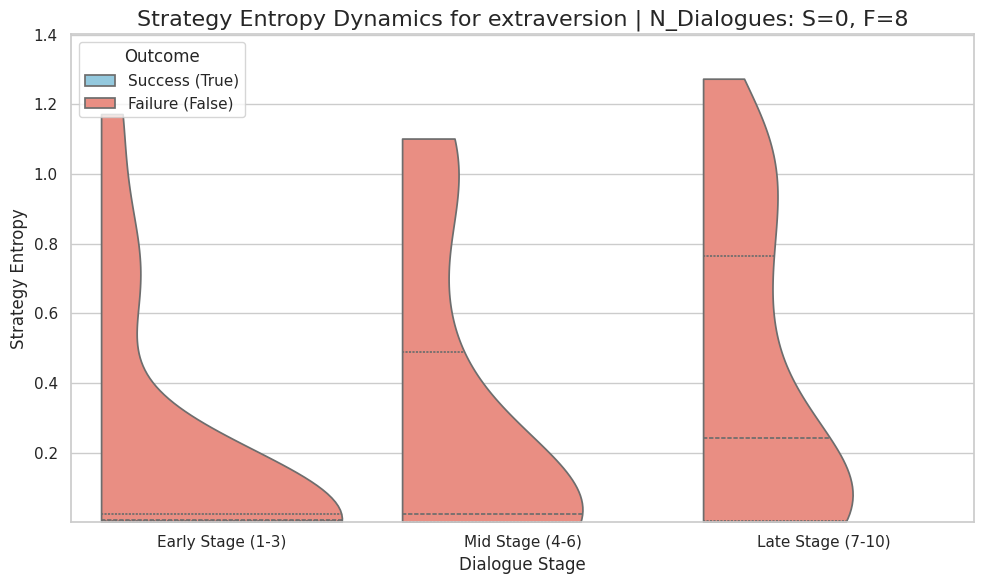

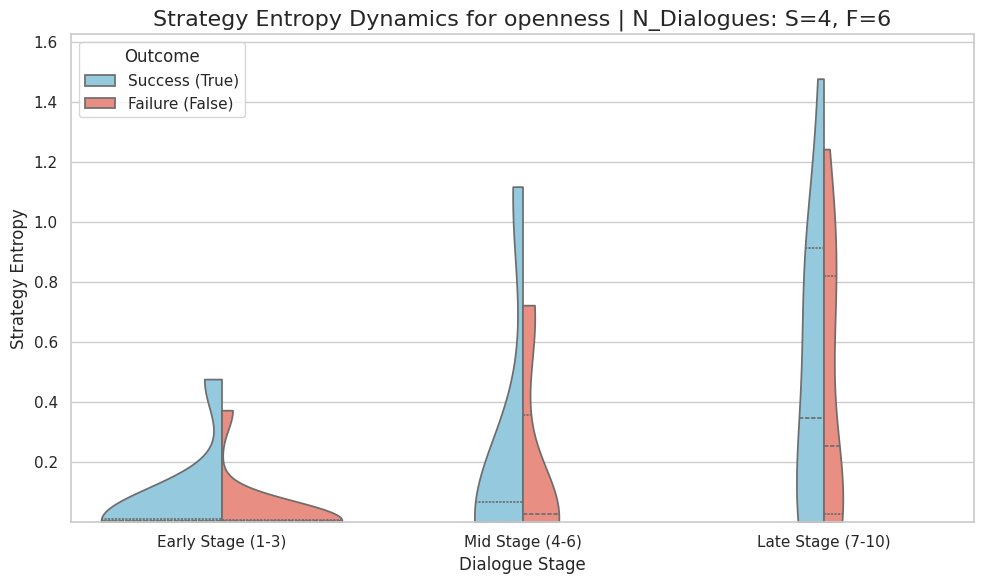

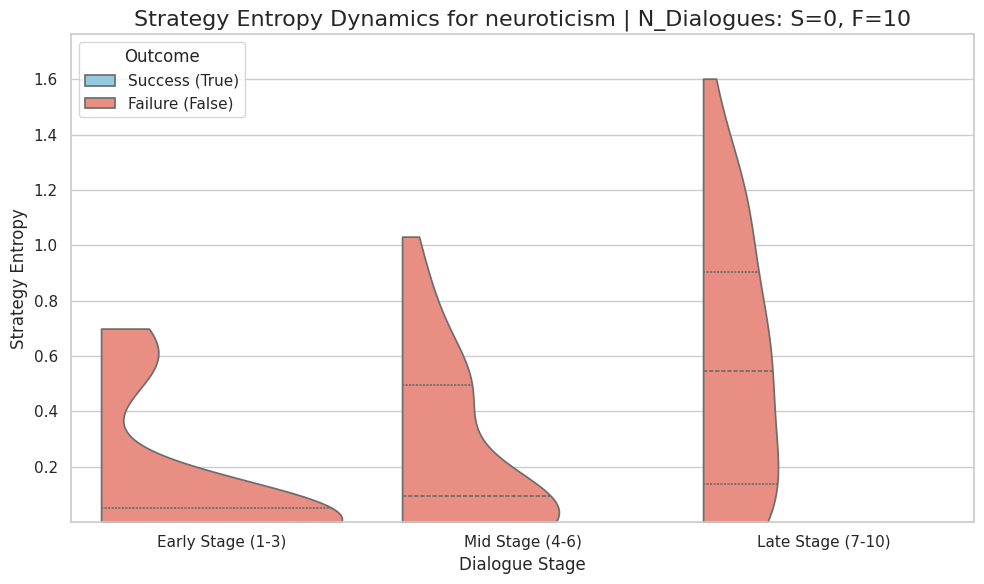

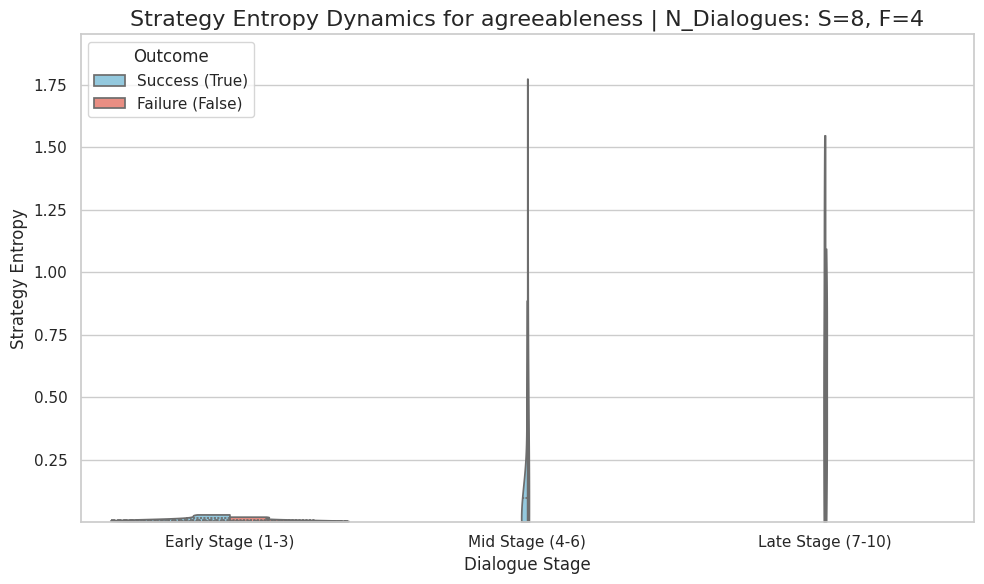

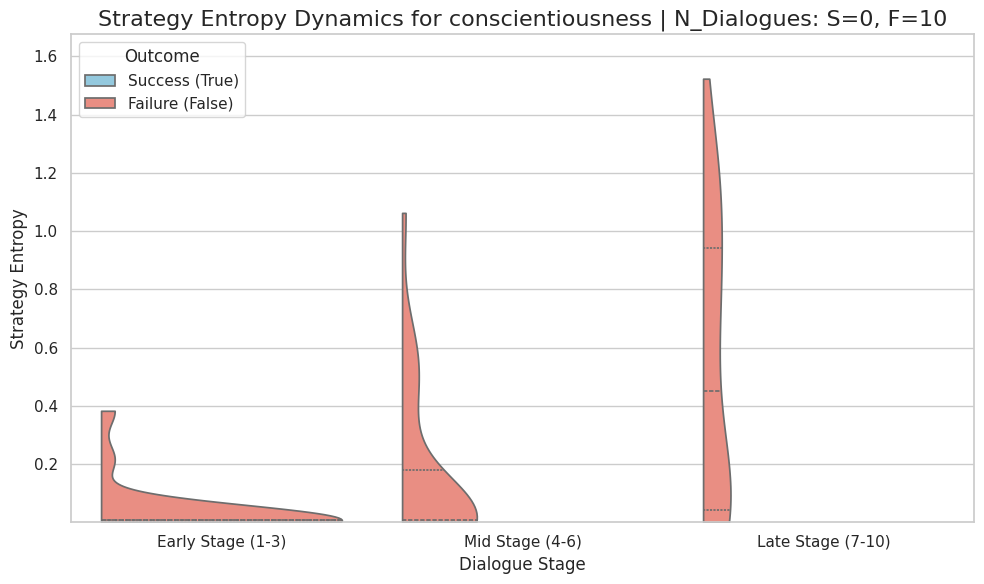


--- 绘制 Decision-Making Style 动态熵分布 ---


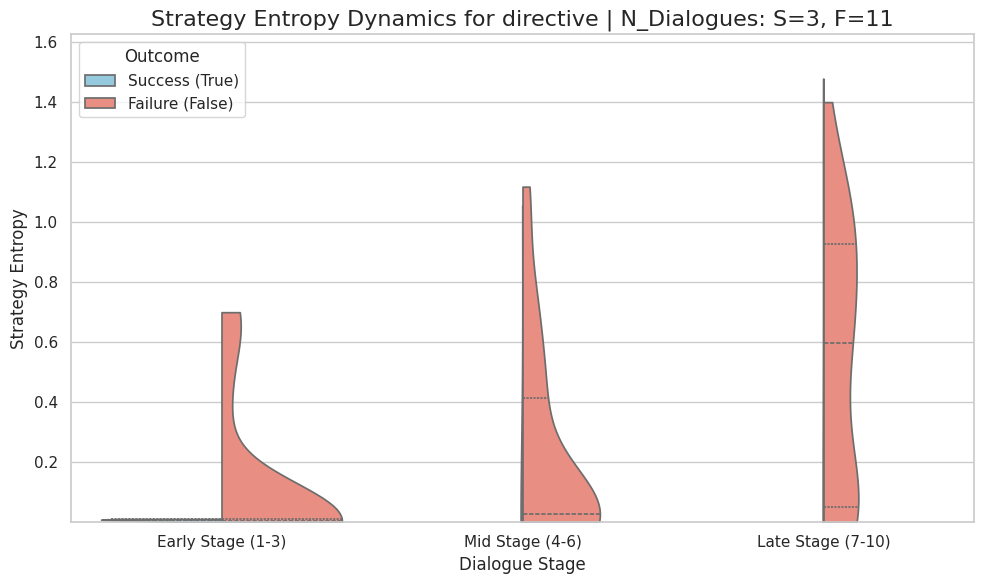

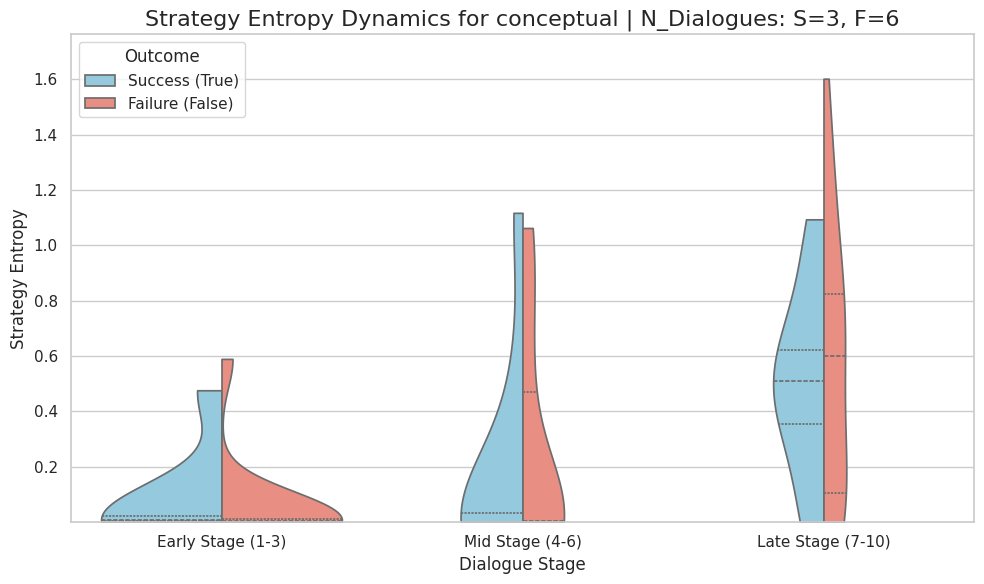

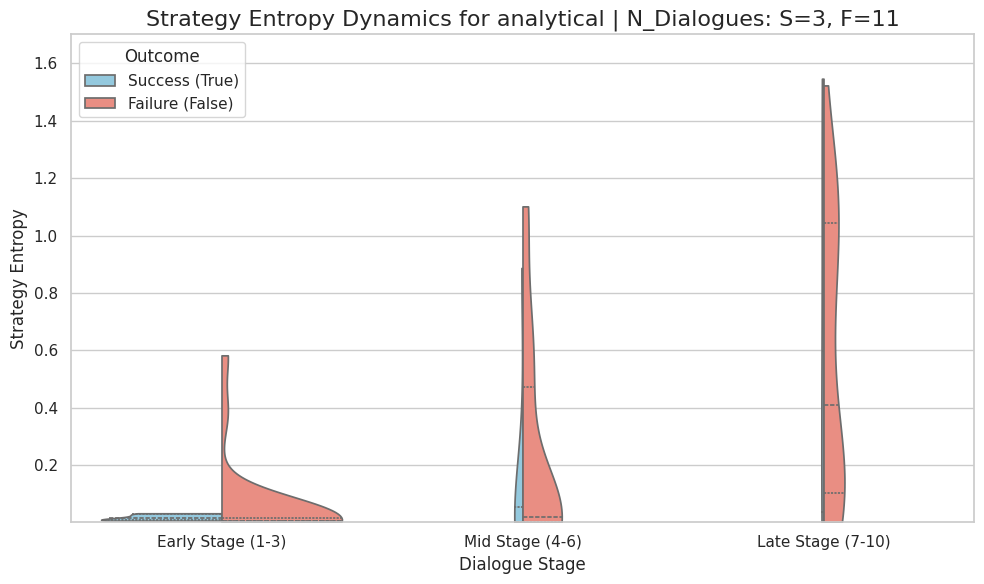

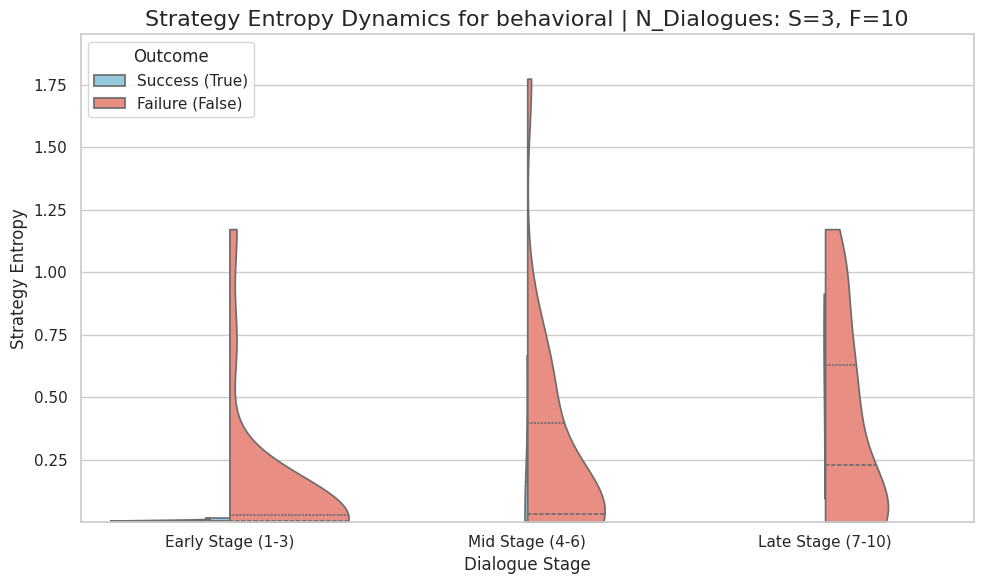

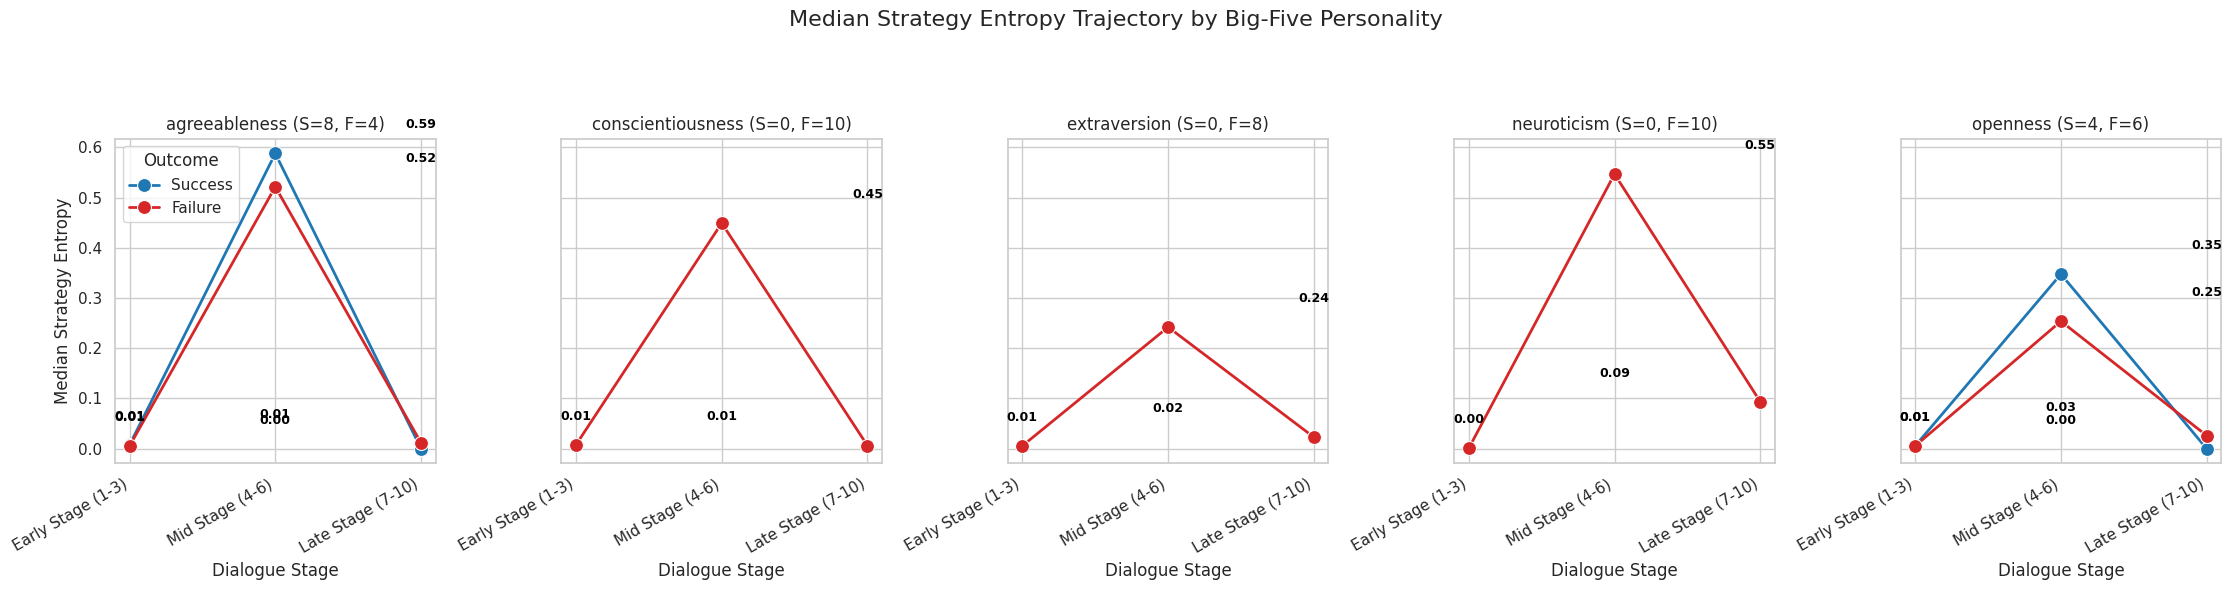

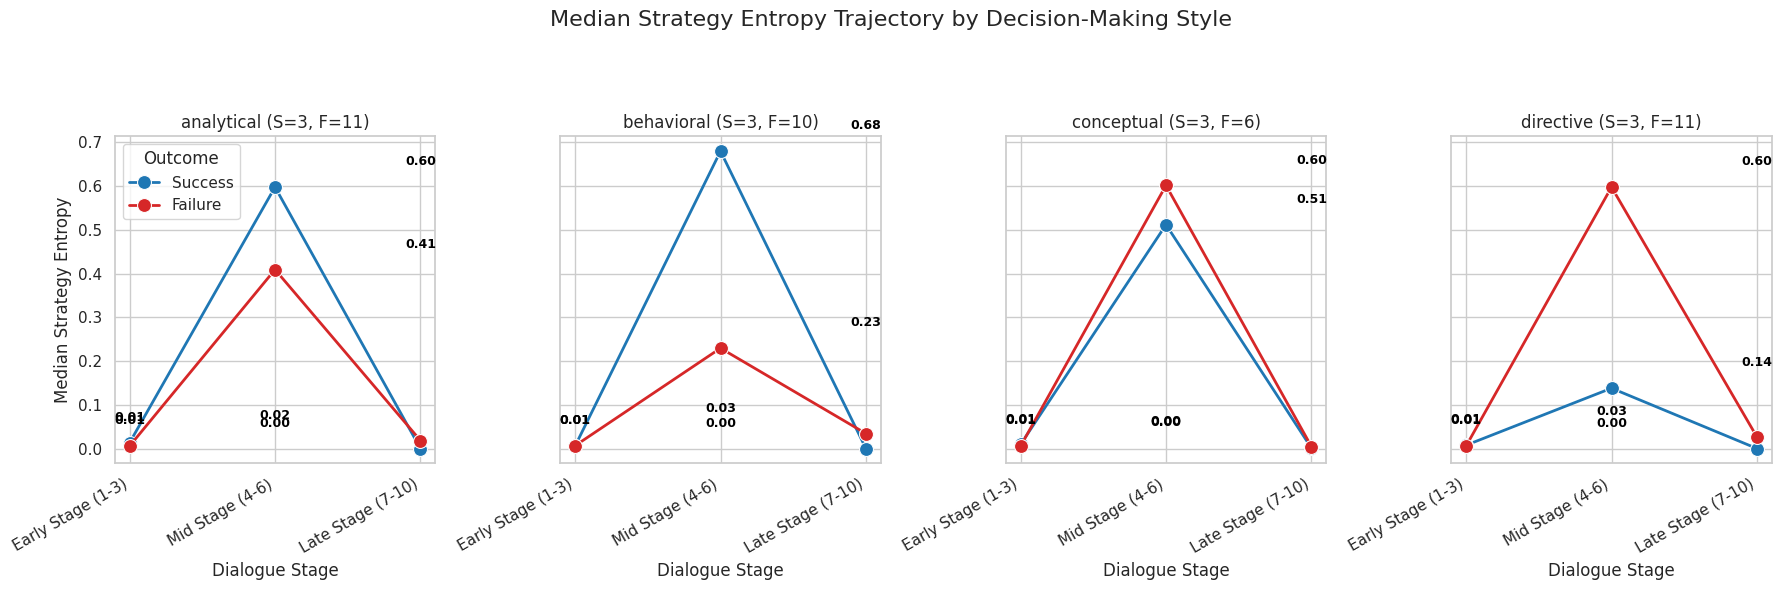

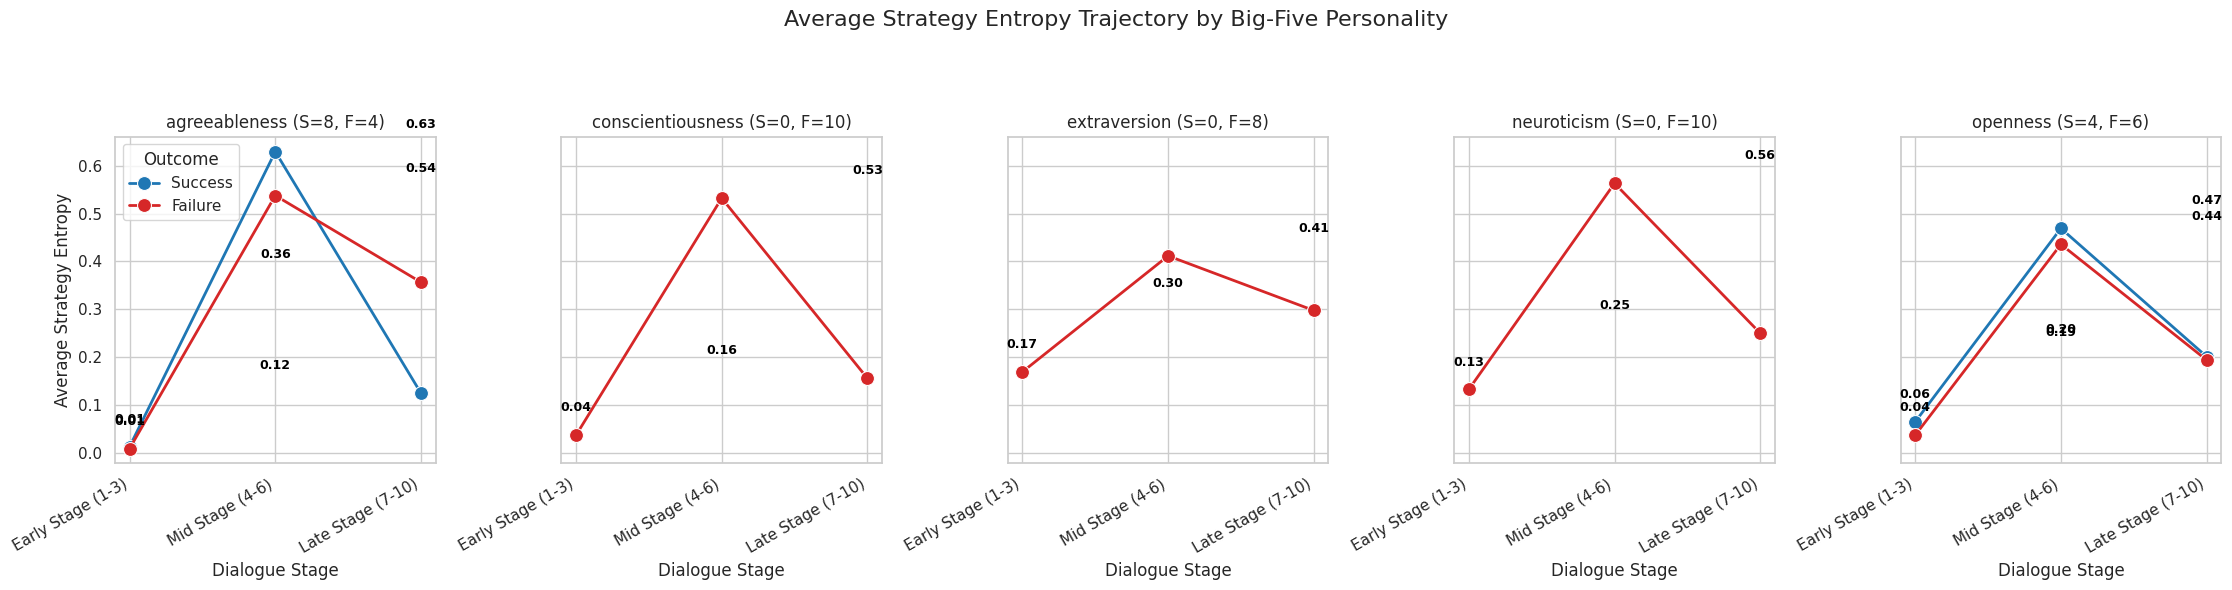

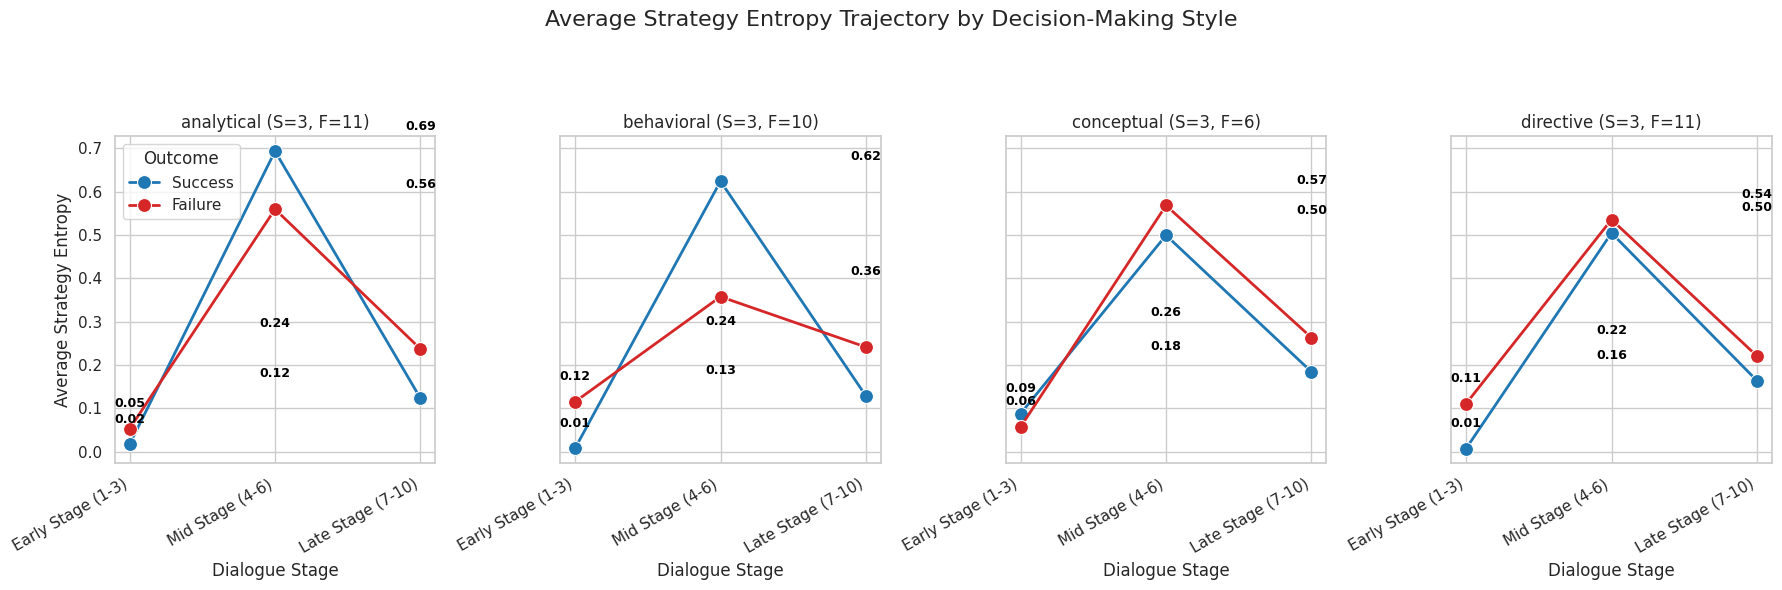

In [ ]:
## 进行不同人格间的熵值分布

def build_dataframe_with_persona(all_data, persona_data):
    """将原始实验结果展平为 DataFrame，并加入人格信息和对话阶段。"""
    records = []
    
    # 由于您的 all_data 只是一个示例片段，这里需要假设 all_data 是一个包含50个用户结果的列表
    for user_record in all_data:
        user_info = user_record['infos']
        user_id = user_info['user_id']
        is_success = user_info['success']
        
        # 1. 获取人格信息
        persona = get_persona_info(user_id, persona_data)
        big_five = persona.get('Big-Five Personality')
        dm_style = persona.get('Decision-Making Style')

        # 2. 遍历轨迹，提取策略数据
        for turn in user_record['trajectory']:
            # 只关心 Persuader 的策略回合，且必须有策略熵
            if turn['role'] == 'Persuader' and 'strategy_entropy' in turn:
                round_num = turn.get('round')
                
                records.append({
                    'user_id': user_id,
                    'success': is_success,
                    'entropy': turn['strategy_entropy'],
                    'round': round_num,
                    'Dialogue_Stage': assign_stage(round_num), # 3. 计算阶段
                    'Big-Five Personality': big_five,
                    'Decision-Making Style': dm_style
                })
    
    df = pd.DataFrame(records)
    # 确保 entropy 列是数字类型
    df['entropy'] = pd.to_numeric(df['entropy'], errors='coerce') 
    return df

def summarize_persona_outcome_counts(df):
    """统计每个人格类型下，成功和失败的独立对话数量。"""
    
    # 由于一个对话包含多轮策略，我们必须先按 'user_id' 和 'success' 分组，确保每个对话只被计数一次
    unique_dialogues = df[['user_id', 'success', 'Big-Five Personality', 'Decision-Making Style']].drop_duplicates()
    
    print("\n--- Big-Five Personality 对话结果统 ---")
    big_five_counts = unique_dialogues.groupby('Big-Five Personality')['success'].value_counts().unstack(fill_value=0)
    big_five_counts.columns = ['Failure Count', 'Success Count']
    big_five_counts['Total'] = big_five_counts['Failure Count'] + big_five_counts['Success Count']
    print(big_five_counts)

    print("\n--- Decision-Making Style 对话结果统计 ---")
    dm_style_counts = unique_dialogues.groupby('Decision-Making Style')['success'].value_counts().unstack(fill_value=0)
    dm_style_counts.columns = ['Failure Count', 'Success Count']
    dm_style_counts['Total'] = dm_style_counts['Failure Count'] + dm_style_counts['Success Count']
    print(dm_style_counts)
    
    return big_five_counts, dm_style_counts

def assign_stage(round_number):
    if 1 <= round_number <= 3:
        return 'Early Stage (1-3)'
    elif 4 <= round_number <= 6:
        return 'Mid Stage (4-6)'
    elif 7 <= round_number <= 10:
        return 'Late Stage (7-10)'
    return None

def plot_single_persona_dynamic_entropy(df, persona_type, persona_value):
    """
    绘制特定人格类型下，策略熵随对话阶段的动态分布图，并区分成功与失败。

    Args:
        df (pd.DataFrame): 包含熵值、成功/失败、阶段和人格信息的DataFrame。
        persona_type (str): 'Big-Five Personality' 或 'Decision-Making Style'。
        persona_value (str): 要绘制的具体人格值（如 'Openness', 'Analytical'）。
    """
    
    # 筛选出特定人格的数据
    data = df[df[persona_type] == persona_value].copy()
    
    if data.empty:
        print(f"数据集中没有找到 {persona_type}: {persona_value} 的数据。")
        return

    # 准备绘图标签
    data['Outcome'] = data['success'].apply(lambda x: 'Success (True)' if x else 'Failure (False)')
    
    # 定义统一的 Hue 顺序：固定 Success 在前（左侧）
    HUE_ORDER = ['Success (True)', 'Failure (False)'] 
    
    # 定义统一的颜色 Palette：Success=蓝色，Failure=红色
    PALETTE = {'Success (True)': 'skyblue', 'Failure (False)': 'salmon'}
    
    # 确保阶段顺序正确
    stage_order = ['Early Stage (1-3)', 'Mid Stage (4-6)', 'Late Stage (7-10)']
    data = data.dropna(subset=['Dialogue_Stage'])

    # 设置绘图风格
    sns.set_theme(style="whitegrid")
    
    plt.figure(figsize=(10, 6))

    # 使用小提琴图绘制
    sns.violinplot(
        x='Dialogue_Stage', 
        y='entropy', 
        hue='Outcome', 
        data=data, 
        order=stage_order,
        split=True,         # 使用 split=True 将成功和失败的小提琴图对半分
        hue_order=HUE_ORDER,
        inner='quartile',   # 在内部显示四分位数
        palette=PALETTE,
        cut=0               # 确保曲线不会过度延伸（尝试解决负值问题）
    )
    
    # 获取总的策略数 (N) 和对话数 (M)
    total_strategies = len(data)
    unique_dialogues = data[['user_id', 'success']].drop_duplicates()
    success_count = unique_dialogues['success'].sum()
    failure_count = len(unique_dialogues) - success_count
    
    plt.title(f'Strategy Entropy Dynamics for {persona_value} | N_Dialogues: S={success_count}, F={failure_count}', fontsize=16)
    plt.xlabel('Dialogue Stage', fontsize=12)
    plt.ylabel('Strategy Entropy', fontsize=12)
    plt.legend(title='Outcome', loc='upper left')
    
    # 尝试设置 Y 轴范围为非负数
    y_min = max(0, data['entropy'].min()) 
    y_max = data['entropy'].max() * 1.1
    plt.ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
def draw_all_persona_dynamics(df):
    """循环调用函数，为所有 Big-Five 和 Decision-Making Style 人格类型绘图。"""
    
    big_five_types = df['Big-Five Personality'].dropna().unique()
    dm_styles = df['Decision-Making Style'].dropna().unique()

    print("\n--- 绘制 Big-Five 人格动态熵分布 ---")
    for p_value in big_five_types:
        plot_single_persona_dynamic_entropy(df, 'Big-Five Personality', p_value)

    print("\n--- 绘制 Decision-Making Style 动态熵分布 ---")
    for p_value in dm_styles:
        plot_single_persona_dynamic_entropy(df, 'Decision-Making Style', p_value)

def plot_persona_median_trajectory_clarified(df, persona_type):
    """
    绘制不同人格下，策略熵中位数随对话阶段的动态轨迹（点图和折线）。

    Args:
        df (pd.DataFrame): 包含熵值、成功/失败、阶段和人格信息的DataFrame。
        persona_type (str): 'Big-Five Personality' 或 'Decision-Making Style'。
    """
    
    df_plot = df.dropna(subset=[persona_type, 'Dialogue_Stage'])
    df_plot['Outcome'] = df_plot['success'].apply(lambda x: 'Success' if x else 'Failure')

    stage_order = ['Early Stage (1-3)', 'Mid Stage (4-6)', 'Late Stage (7-10)']
    
    # 计算每个分组的中位数
    entropy_summary = df_plot.groupby([persona_type, 'Dialogue_Stage', 'Outcome'])['entropy'].median().reset_index()
    
    # 计算每个分组的样本量（用于标题标注）
    count_summary = df_plot.groupby([persona_type, 'Outcome'])['user_id'].nunique().unstack(fill_value=0)
    
    categories = entropy_summary[persona_type].unique()
    categories.sort() 
    
    n_categories = len(categories)
    
    sns.set_theme(style="whitegrid")
    
    # 动态调整图表大小
    fig, axes = plt.subplots(1, n_categories, figsize=(4.5 * n_categories, 6), sharey=True)
    
    if n_categories == 1:
        axes = [axes] 

    fig.suptitle(f'Median Strategy Entropy Trajectory by {persona_type}', fontsize=16)

    for i, category in enumerate(categories):
        ax = axes[i]
        data = entropy_summary[entropy_summary[persona_type] == category]
        
        # 获取成功/失败的对话数量
        s_count = count_summary.loc[category, 'Success'] if category in count_summary.index and 'Success' in count_summary.columns else 0
        f_count = count_summary.loc[category, 'Failure'] if category in count_summary.index and 'Failure' in count_summary.columns else 0

        # 绘制折线图和点图 (Line Plot with Markers)
        sns.lineplot(
            x='Dialogue_Stage', 
            y='entropy', 
            hue='Outcome', 
            data=data, 
            ax=ax, 
            marker='o',
            markersize=10,
            linewidth=2,
            palette={'Success': 'tab:blue', 'Failure': 'tab:red'},
            dashes=False, 
            sort=False,
            hue_order=['Success', 'Failure'] # 统一顺序
        )
        
        ax.set_title(f'{category} (S={s_count}, F={f_count})', fontsize=12)
        ax.set_xlabel('Dialogue Stage')
        ax.set_xticks(range(len(stage_order)))
        ax.set_xticklabels(stage_order, rotation=30, ha='right')
        
        # 标注每个点上的中位数值
        for _, row in data.iterrows():
            ax.text(
                stage_order.index(row['Dialogue_Stage']), 
                row['entropy'] + 0.05, # 稍微向上偏移
                f"{row['entropy']:.2f}",
                size=9,
                color='black',
                ha='center',
                weight='bold'
            )

        if i == 0:
            ax.set_ylabel('Median Strategy Entropy', fontsize=12)
            ax.legend(title='Outcome')
        else:
            ax.set_ylabel('')
            ax.legend([],[], frameon=False) 

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

def plot_persona_mean_trajectory_clarified(df, persona_type):
    """
    绘制不同人格下，策略熵平均值随对话阶段的动态轨迹（点图和折线）。

    Args:
        df (pd.DataFrame): 包含熵值、成功/失败、阶段和人格信息的DataFrame。
        persona_type (str): 'Big-Five Personality' 或 'Decision-Making Style'。
    """
    
    df_plot = df.dropna(subset=[persona_type, 'Dialogue_Stage'])
    df_plot['Outcome'] = df_plot['success'].apply(lambda x: 'Success' if x else 'Failure')

    stage_order = ['Early Stage (1-3)', 'Mid Stage (4-6)', 'Late Stage (7-10)']
    
    # *** 关键修改：计算每个分组的平均值 (.mean()) ***
    entropy_summary = df_plot.groupby([persona_type, 'Dialogue_Stage', 'Outcome'])['entropy'].mean().reset_index()
    
    # 计算每个分组的样本量（用于标题标注）
    # 注意：此处需要计算独立对话数量，而不是策略回合数
    count_summary = df_plot.groupby([persona_type, 'Outcome'])['user_id'].nunique().unstack(fill_value=0)
    
    categories = entropy_summary[persona_type].unique()
    categories.sort() 
    
    n_categories = len(categories)
    
    sns.set_theme(style="whitegrid")
    
    fig, axes = plt.subplots(1, n_categories, figsize=(4.5 * n_categories, 6), sharey=True)
    
    if n_categories == 1:
        axes = [axes] 

    # 更新标题：使用 Average Strategy Entropy
    fig.suptitle(f'Average Strategy Entropy Trajectory by {persona_type}', fontsize=16)

    for i, category in enumerate(categories):
        ax = axes[i]
        data = entropy_summary[entropy_summary[persona_type] == category]
        
        # 获取成功/失败的对话数量
        s_count = count_summary.loc[category, 'Success'] if category in count_summary.index and 'Success' in count_summary.columns else 0
        f_count = count_summary.loc[category, 'Failure'] if category in count_summary.index and 'Failure' in count_summary.columns else 0

        # 绘制折线图和点图 
        sns.lineplot(
            x='Dialogue_Stage', 
            y='entropy', 
            hue='Outcome', 
            data=data, 
            ax=ax, 
            marker='o',
            markersize=10,
            linewidth=2,
            palette={'Success': 'tab:blue', 'Failure': 'tab:red'},
            dashes=False, 
            sort=False,
            hue_order=['Success', 'Failure'] 
        )
        
        ax.set_title(f'{category} (S={s_count}, F={f_count})', fontsize=12)
        ax.set_xlabel('Dialogue Stage')
        ax.set_xticks(range(len(stage_order)))
        ax.set_xticklabels(stage_order, rotation=30, ha='right')
        
        # 标注每个点上的平均数值
        for _, row in data.iterrows():
            ax.text(
                stage_order.index(row['Dialogue_Stage']), 
                row['entropy'] + 0.05, 
                f"{row['entropy']:.2f}",
                size=9,
                color='black',
                ha='center',
                weight='bold'
            )

        if i == 0:
            # 更新Y轴标签
            ax.set_ylabel('Average Strategy Entropy', fontsize=12)
            ax.legend(title='Outcome')
        else:
            ax.set_ylabel('')
            ax.legend([],[], frameon=False) 

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

"""
分析不同人格上的熵分布：
1）小提琴图
2）中位数
"""
if __name__ == '__main__':
    persona_data = load_data(r"/root/EvolvingAgent-master/EvolvingAgentTest/user_personas.json")
    result_data = load_data(r"/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v9.json")
    
    for key, value in persona_data.items():
        value['Big-Five Personality'] = value['Big-Five Personality'].lower()
        value['Decision-Making Style'] = value['Decision-Making Style'].lower()
        
    df = build_dataframe_with_persona(all_data=result_data, persona_data=persona_data)
    
    summarize_persona_outcome_counts(df=df)
    
    ## 进行前中后期阶段的划分
    draw_all_persona_dynamics(df=df)
    
    plot_persona_median_trajectory_clarified(df, persona_type="Big-Five Personality")
    plot_persona_median_trajectory_clarified(df, persona_type="Decision-Making Style")
    
    plot_persona_mean_trajectory_clarified(df, persona_type="Big-Five Personality")
    plot_persona_mean_trajectory_clarified(df, persona_type="Decision-Making Style")

## 和专家判断的对比

1）看策略的熵值是否与外部模型专家判断的一致

In [18]:
# 辅助函数：根据回合查找专家判断
def get_expert_judgement(judge_result, turn_num):
    """从 judge_result 中提取特定回合的快慢思考判断和阶段起始标记。"""
    
    is_stage_start = False
    is_slow_thinking = None
    
    # 检查是否为阶段起始回合
    if 'stage_seg_result' in judge_result:
        for stage in judge_result['stage_seg_result']:
            if turn_num == stage['turns'][0]:
                is_stage_start = True
                break
                
    # 提取快慢思考类型
    if 'strategy_judge_result' in judge_result:
        for judgment in judge_result['strategy_judge_result']:
            if turn_num == judgment['turn']:
                is_slow_thinking = (judgment['thinking_type'] == 'Slow')
                break
                
    return is_stage_start, is_slow_thinking

def build_dataframe_with_expert_judgement(all_data, persona_data):
    """在原有基础上，加入专家判断的快慢思考类型和阶段起始标记。"""
    records = []
    
    for user_record in all_data:
        user_info = user_record['infos']
        user_id = user_info['user_id']
        
        # 提取人格信息 (假设 persona_data 已加载)
        persona = get_persona_info(user_id, persona_data)
        big_five = persona.get('Big-Five Personality')
        dm_style = persona.get('Decision-Making Style')

        judge_result = user_record.get('judge_result', {})
        is_success = user_info.get('success', False)

        # 遍历轨迹
        for turn in user_record['trajectory']:
            if turn['role'] == 'Persuader' and 'strategy_entropy' in turn:
                round_num = turn.get('round')
                
                # 提取专家判断结果
                is_stage_start, is_slow_thinking = get_expert_judgement(judge_result, round_num)
                strategy_name = turn.get('strategy') 
                records.append({
                    # ... 基础信息
                    'user_id': user_id,
                    'success': is_success,
                    'entropy': pd.to_numeric(turn['strategy_entropy'], errors='coerce'),
                    'round': round_num,
                    'Dialogue_Stage': assign_stage(round_num),
                    'Big-Five Personality': big_five,
                    'Decision-Making Style': dm_style,
                    # 添加策略名称
                    'strategy': strategy_name, # <-- 确保策略名被记录
                    # 专家判断列
                    'Is_Stage_Start': is_stage_start,
                    'Is_Slow_Thinking': is_slow_thinking
                })
    
    return pd.DataFrame(records).dropna(subset=['entropy', 'Is_Slow_Thinking'])


In [19]:
import warnings
import pandas as pd
# ... 其他必要的导入 ...

# 在文件顶部设置，忽略所有警告
warnings.filterwarnings("ignore")
 


--- 策略熵 vs. 快/慢思考 (Fast/Slow Thinking) 分析 ---
| Thinking Type           |   Strategy Count |   Average Entropy |   Median Entropy |
|:------------------------|-----------------:|------------------:|-----------------:|
| Fast Thinking (Routine) |               22 |          0.576434 |        0.585938  |
| Slow Thinking (Complex) |              325 |          0.295279 |        0.0251465 |


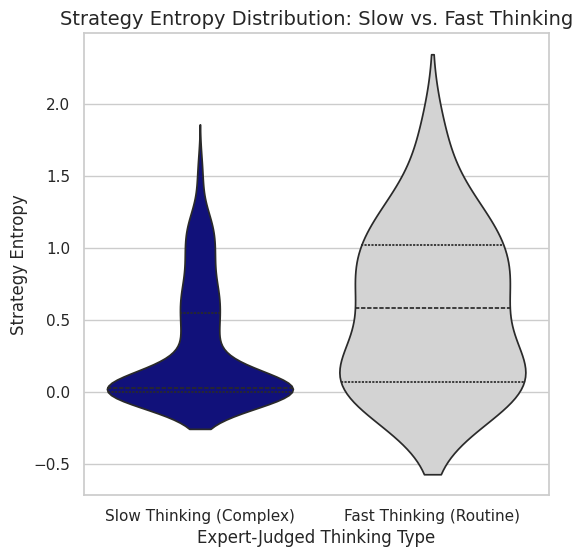


--- 策略熵 vs. 阶段起始点 (Stage Start) 分析 ---
| Position               |   Strategy Count |   Average Entropy |   Median Entropy |
|:-----------------------|-----------------:|------------------:|-----------------:|
| Mid-Stage Action       |              211 |          0.402703 |       0.21582    |
| Stage Start (Key Turn) |              136 |          0.174095 |       0.00750732 |


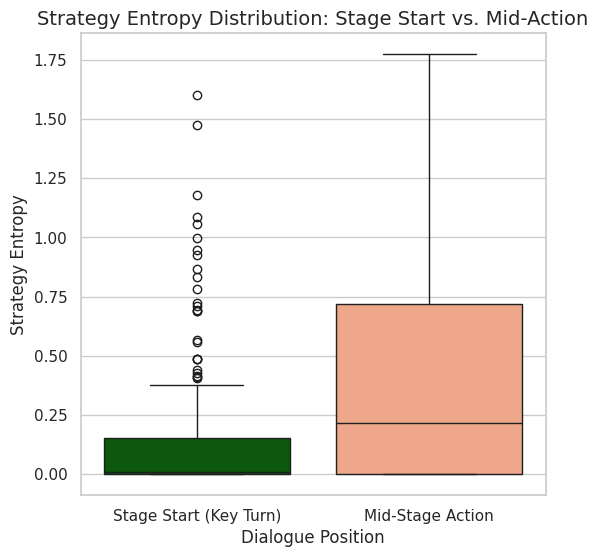


--- 高熵策略分析 (Entropy > 0.225) ---

[表 A: 高熵策略类型分布 (策略功能归类需要手动添加)]
| 策略类型                                                                                                 |   总出现次数 | 成功百分比   | 失败百分比   |
|:---------------------------------------------------------------------------------------------------------|-------------:|:-------------|:-------------|
| Foot in the Door                                                                                         |           53 | 7 (13%)      | 46 (87%)     |
| Source Related Inquiry                                                                                   |           22 | 4 (18%)      | 18 (82%)     |
| Task Related Inquiry                                                                                     |           18 | 3 (17%)      | 15 (83%)     |
| Credibility Appeal                                                                                       |           13 | 1 (8%)       | 12 (92%)     |
| Self Modeling              

In [21]:
def analyze_entropy_vs_thinking_type(df):
    """对比快思考和慢思考策略的策略熵分布。"""
    
    print("\n--- 策略熵 vs. 快/慢思考 (Fast/Slow Thinking) 分析 ---")
    
    # 统计平均熵和样本量 (使用 analysis DataFrame)
    analysis = df.groupby('Is_Slow_Thinking')['entropy'].agg(['mean', 'median', 'count']).reset_index()
    analysis.rename(columns={'mean': 'Average Entropy', 'median': 'Median Entropy', 'count': 'Strategy Count'}, inplace=True)
    
    analysis['Thinking Type'] = analysis['Is_Slow_Thinking'].apply(lambda x: 'Slow Thinking (Complex)' if x else 'Fast Thinking (Routine)')
    
    print(analysis[['Thinking Type', 'Strategy Count', 'Average Entropy', 'Median Entropy']].to_markdown(index=False))
    
    # --- 修正点 1: 创建用于绘图的 DataFrame (plot_df) ---
    plot_df = df.copy()
    plot_df['Thinking Type'] = plot_df['Is_Slow_Thinking'].apply(lambda x: 'Slow Thinking (Complex)' if x else 'Fast Thinking (Routine)')
    
    # 定义统一的顺序
    order = ['Slow Thinking (Complex)', 'Fast Thinking (Routine)']
    
    # 可视化：小提琴图对比
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(6, 6))
    sns.violinplot(
        x='Thinking Type', 
        y='entropy', 
        data=plot_df, # 使用修正后的 DataFrame
        order=order, # 强制指定顺序
        inner='quartile',
        palette={'Slow Thinking (Complex)': 'darkblue', 'Fast Thinking (Routine)': 'lightgray'}
    )
    plt.title('Strategy Entropy Distribution: Slow vs. Fast Thinking', fontsize=14)
    plt.xlabel('Expert-Judged Thinking Type', fontsize=12)
    plt.ylabel('Strategy Entropy', fontsize=12)
    plt.show()
# 为什么这么分析？
# 如果 Is_Slow_Thinking=True 的平均熵和中位数显著更高，那么我们就找到了
# 连接模型内部机制（熵）和外部功能（慢思考/复杂规划）的直接证据。
# 这意味着高熵时刻正是模型投入“认知资本”进行深入规划的时刻。
    
def analyze_entropy_vs_stage_start(df):
    """对比阶段起始回合与其他回合的策略熵分布。"""
    
    print("\n--- 策略熵 vs. 阶段起始点 (Stage Start) 分析 ---")
    
    # 统计平均熵和样本量
    analysis = df.groupby('Is_Stage_Start')['entropy'].agg(['mean', 'median', 'count']).reset_index()
    analysis.rename(columns={'mean': 'Average Entropy', 'median': 'Median Entropy', 'count': 'Strategy Count'}, inplace=True)
    
    analysis['Position'] = analysis['Is_Stage_Start'].apply(lambda x: 'Stage Start (Key Turn)' if x else 'Mid-Stage Action')
    
    print(analysis[['Position', 'Strategy Count', 'Average Entropy', 'Median Entropy']].to_markdown(index=False))

    # --- 修正点 2: 创建用于绘图的 DataFrame (plot_df) ---
    plot_df = df.copy()
    plot_df['Position'] = plot_df['Is_Stage_Start'].apply(lambda x: 'Stage Start (Key Turn)' if x else 'Mid-Stage Action')
    
    # 定义统一的顺序
    order = ['Stage Start (Key Turn)', 'Mid-Stage Action']

    # 可视化：箱线图对比
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(6, 6))
    sns.boxplot(
        x='Position', 
        y='entropy', 
        data=plot_df, # 使用修正后的 DataFrame
        order=order, # 强制指定顺序
        palette={'Stage Start (Key Turn)': 'darkgreen', 'Mid-Stage Action': 'lightsalmon'}
    )
    plt.title('Strategy Entropy Distribution: Stage Start vs. Mid-Action', fontsize=14)
    plt.xlabel('Dialogue Position', fontsize=12)
    plt.ylabel('Strategy Entropy', fontsize=12)
    plt.show()
    
# 为什么这么分析？
# 如果 Is_Stage_Start=True 的熵值更高，说明模型在需要进行“策略转型”或“铺垫长期策略”时，
# 内部的不确定性最高。这证实了高熵策略的信用价值在于其“引导性”和“方向性”。

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_high_entropy_strategies(df, entropy_threshold=0.225):
    """
    分析策略熵高于阈值的策略的类型、时间分布和成功率。
    
    Args:
        df (pd.DataFrame): 包含所有策略回合信息的DataFrame。
        entropy_threshold (float): 高熵策略的筛选阈值 (70% Quantile)。
    """
    
    # 筛选高熵策略
    high_entropy_df = df[df['entropy'] > entropy_threshold].copy()
    
    if high_entropy_df.empty:
        print(f"没有策略熵高于 {entropy_threshold} 的数据。")
        return

    print(f"\n--- 高熵策略分析 (Entropy > {entropy_threshold:.3f}) ---")
    
    # ===================================================================
    # PART A: 策略类型分布统计 (基础统计，保持不变)
    # ===================================================================
    
    strategy_counts = high_entropy_df.groupby('strategy')['success'].agg(
        total_count='count',
        success_count=lambda x: (x == True).sum(),
        failure_count=lambda x: (x == False).sum()
    ).reset_index()

    strategy_counts['Success Rate (%)'] = (strategy_counts['success_count'] / strategy_counts['total_count']) * 100
    strategy_counts['Failure Count (%)'] = 100 - strategy_counts['Success Rate (%)']
    
    strategy_counts = strategy_counts.rename(columns={'strategy': '策略类型', 'total_count': '总出现次数', 
                                                     'success_count': '成功对话中出现次数 (True)', 
                                                     'failure_count': '失败对话中出现次数 (False)'})
    
    strategy_counts['成功百分比'] = strategy_counts.apply(
        lambda row: f"{row['成功对话中出现次数 (True)']} ({row['Success Rate (%)']:.0f}%)", axis=1
    )
    strategy_counts['失败百分比'] = strategy_counts.apply(
        lambda row: f"{row['失败对话中出现次数 (False)']} ({row['Failure Count (%)']:.0f}%)", axis=1
    )
    
    output_table_A = strategy_counts[['策略类型', '总出现次数', '成功百分比', '失败百分比']].sort_values(by='总出现次数', ascending=False)
    
    print("\n[表 A: 高熵策略类型分布 (策略功能归类需要手动添加)]")
    print(output_table_A.to_markdown(index=False))

    # ===================================================================
    # PART A.1 (新增): 策略类型 × 阶段交叉分析
    # ===================================================================
    
    # 按照策略类型和对话阶段进行分组计数
    cross_stage_counts = high_entropy_df.groupby(['strategy', 'Dialogue_Stage']).size().unstack(fill_value=0)
    
    # 确保列顺序是阶段顺序
    stage_order = ['Early Stage (1-3)', 'Mid Stage (4-6)', 'Late Stage (7-10)']
    
    # 检查 cross_stage_counts 的列中是否存在缺失的阶段，并添加
    for stage in stage_order:
        if stage not in cross_stage_counts.columns:
            cross_stage_counts[stage] = 0
            
    cross_stage_counts = cross_stage_counts[stage_order]

    # 合并到基础统计表，以便按总数排序
    output_table_A1 = output_table_A[['策略类型', '总出现次数']].set_index('策略类型')
    cross_stage_counts.index.name = '策略类型'
    
    # 将阶段计数合并到输出表A1
    final_cross_table = output_table_A1.join(cross_stage_counts, how='left').reset_index()
    final_cross_table = final_cross_table.sort_values(by='总出现次数', ascending=False)
    
    print("\n[表 A.1: 高熵策略类型在对话阶段的分布数量]")
    print(final_cross_table.to_markdown(index=False))

    # ===================================================================
    # PART B: 时间（阶段）分布统计 (保持不变)
    # ===================================================================
    
    stage_counts = high_entropy_df.groupby('Dialogue_Stage')['success'].agg(
        total_count='count',
        success_count=lambda x: (x == True).sum(),
        failure_count=lambda x: (x == False).sum()
    ).reset_index()

    stage_counts['Success Rate (%)'] = (stage_counts['success_count'] / stage_counts['total_count']) * 100
    stage_counts['Failure Count (%)'] = 100 - stage_counts['Success Rate (%)']

    stage_counts['Dialogue_Stage'] = pd.Categorical(stage_counts['Dialogue_Stage'], categories=stage_order, ordered=True)
    stage_counts = stage_counts.sort_values('Dialogue_Stage')

    stage_counts = stage_counts.rename(columns={'Dialogue_Stage': '阶段', 'total_count': '高熵策略总数'})
    stage_counts['成功百分比'] = stage_counts.apply(
        lambda row: f"{row['success_count']} ({row['Success Rate (%)']:.0f}%)", axis=1
    )
    stage_counts['失败百分比'] = stage_counts.apply(
        lambda row: f"{row['failure_count']} ({row['Failure Count (%)']:.0f}%)", axis=1
    )

    output_table_B = stage_counts[['阶段', '高熵策略总数', '成功百分比', '失败百分比']]
    
    print("\n[表 B: 高熵策略时间（阶段）分布]")
    print(output_table_B.to_markdown(index=False))
    
    return high_entropy_df

if __name__ == '__main__':
    persona_data = load_data(r"/root/EvolvingAgent-master/EvolvingAgentTest/user_personas.json")
    result_data = load_data(r"/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v8.json")
    
    for key, value in persona_data.items():
        value['Big-Five Personality'] = value['Big-Five Personality'].lower()
        value['Decision-Making Style'] = value['Decision-Making Style'].lower()
        
    # df = build_dataframe_with_persona(all_data=result_data, persona_data=persona_data)
    df = build_dataframe_with_expert_judgement(all_data=result_data, persona_data=persona_data)
    
    ## 分析策略熵和快慢思考
    analyze_entropy_vs_thinking_type(df)
    
    ## 分析策略熵和阶段转折点
    analyze_entropy_vs_stage_start(df)
    
    ## 定性分析策略
    high_entropy_subset_df = analyze_high_entropy_strategies(df, entropy_threshold=0.225)

## 分析FITD策略

In [7]:
"""
1) 获取和分析FITD策略的应用情况
"""
import json
result_path = r"/root/EvolvingAgent-master/EvolvingAgentTest/model/Motivation/results_v9.json"

with open(result_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(len(data))

persona_path = r"/root/EvolvingAgent-master/EvolvingAgentTest/user_personas.json"

for idx, item in enumerate(data):
    traj = item['trajectory']
    person_id = item['infos']['user_id']
    success = item['infos']['success']
    for utt in traj:
        if "strategy" in utt:
            if utt['strategy'].lower() == "foot in the door":
                print(f"User_ID:{person_id} Success:{success} Turn:{utt['round']} Utterance: {utt['content']}")

50
User_ID:persona_58 Success:False Turn:5 Utterance: That’s completely understandable, and I completely respect that. Even a small contribution, like $1 or $2, can make a meaningful difference. Would you be open to starting with something small to see how it feels?
User_ID:persona_58 Success:False Turn:10 Utterance: I completely understand that taking time to think is important. If you ever feel ready, even a small donation like $1 or $2 can be the start of something meaningful. You can always come back to this whenever you're ready to make a difference.
User_ID:persona_13 Success:False Turn:7 Utterance: That’s completely understandable—many people feel the same way. How about we start with a small donation, like $1, to see how it can make a difference? It’s a simple way to begin supporting children in need.
User_ID:persona_141 Success:False Turn:5 Utterance: I completely understand your concern, and that's why I suggest starting with a small donation, like $1, to see how it can make 

# 处理熵值数据

In [1]:
import json
import numpy as np
import os
import argparse
from tqdm import tqdm

from model.Motivation.analysis_add_strategy_reason.analysis_token import *

def str2bool(value):
    if isinstance(value, bool):
        return value
    if value.lower() in ("true", "t", "1"):
        return True
    elif value.lower() in ("false", "f", "0"):
        return False
    else:
        raise argparse.ArgumentTypeError("Boolean value expected.")

def calculate_mean_entropy(tokens):
    if not tokens: return 0.0
    return np.mean([t['entropy'] for t in tokens])

def process_data(input_file, output_dir):
    print(f"Loading data from {input_file}...")
    with open(input_file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    summary_records = []  # 存储每轮的统计摘要
    detailed_records = [] # 存储包含所有Token的大文件结构

    all_hs_values = []
    all_ha_values = []

    user_persona = json.load(open(r"/root/EvolvingAgent-master/EvolvingAgentTest/user_personas.json", 'r', encoding='utf-8'))

    print("Processing trajectories...")
    
    for episode in tqdm(data):
        user_id = episode.get('user_id', 'Unknown')
        detailed_history = episode.get('detailed_history', [])
        
        episode_summary = {
            "user_id": user_id,
            "success": episode.get('success', False),
            "user_profile": episode.get('user_profile', {}),
            "Big-Five Personality": user_persona.get(user_id, {}).get('Big-Five Personality', 'Unknown'),
            "Decision-Making Style": user_persona.get(user_id, {}).get('Decision-Making Style', 'Unknown'),
            "episode": [],
        }
        
        # 用于计算 Z-Score 的历史缓存
        history_hs = []
        
        # 详细记录结构保持与原始类似，但会清洗掉未使用的字段
        episode_detail = {
            "user_id": user_id,
            "success": episode.get('success', False),
            "turns": episode.get('turns', []),
            "episode": [],
        }

        for turn in detailed_history:
            # 只处理 Persuader (System) 的回合
            if turn['role'] == 'Persuader':
                metrics = turn.get('metrics', [])
                if not metrics: continue

                # 1. 切分阶段
                state_tokens, strategy_tokens, response_tokens = segment_metrics_new_format(metrics)
                
                # 2. 计算平均熵
                hs = calculate_mean_entropy(state_tokens)
                ha = calculate_mean_entropy(strategy_tokens)
                hr = calculate_mean_entropy(response_tokens)
                
                all_hs_values.append(hs)
                all_ha_values.append(ha)
                
                # 3. 计算 Z-Score (基于 State Entropy)
                # Z = (Current - Mean_History) / Std_History
                if len(history_hs) < 2:
                    z_score_hs = 0.0 # 冷启动
                else:
                    mean_hist = np.mean(history_hs)
                    std_hist = np.std(history_hs) + 1e-6
                    z_score_hs = (hs - mean_hist) / std_hist
                
                # 更新历史
                history_hs.append(hs)
                
                # 4. 存入 Summary
                turn_summary = {
                    "role": "Persuader",
                    "round": turn['round'],
                    "content": turn.get("content", ""),
                    "hs": hs, # State Entropy
                    "ha": ha, # Strategy Entropy
                    "hr": hr, # Response Entropy
                    "z_score_hs": z_score_hs,
                    "strategy_name": turn.get("strategy_name", ""),
                    "strategy_reason": turn.get("strategy_reason", ""),
                    "state_analysis": turn.get("state_analysis", ""),
                }
                episode_summary['episode'].append(turn_summary)
                
                turn_detail = {
                    "role": "Persuader",
                    "round": turn['round'],
                    "metrics": turn.get('metrics', []),
                }
                episode_detail['episode'].append(turn_detail)
            
            else:
                # User (Persuadee) Turn
                episode_summary['episode'].append({
                    "role": "Persuadee",
                    "round": turn['round'],
                    "content": turn.get("content", "")
                })
                episode_detail['episode'].append({
                    "role": "Persuadee",
                    "round": turn['round'],
                    "content": turn.get("content", "")
                })
        summary_records.append(episode_summary)
        detailed_records.append(episode_detail)

    # 4. 计算全局分位数
    print("Calculating global statistics...")
    hs_array = np.array(all_hs_values)
    ha_array = np.array(all_ha_values)
    
    global_stats = {
        "hs_mean": float(np.mean(hs_array)),
        "hs_std": float(np.std(hs_array)),
        "hs_top_20": float(np.percentile(hs_array, 80)), # Q3
        "hs_top_10": float(np.percentile(hs_array, 90)),
        
        "ha_mean": float(np.mean(ha_array)),
        "ha_std": float(np.std(ha_array)),
        "ha_bottom_20": float(np.percentile(ha_array, 80)), # Q1
        "ha_bottom_10": float(np.percentile(ha_array, 10))
    }
    
    print("\n=== Global Entropy Statistics ===")
    print(json.dumps(global_stats, indent=2))
    
    # 5. 将全局统计信息写入 Summary 文件头部或单独文件
    final_summary = {
        "global_stats": global_stats,
        "episodes": summary_records
    }
    
    # 6. 保存文件
    os.makedirs(output_dir, exist_ok=True)
    
    summary_path = os.path.join(output_dir, "summary_stats.json")
    detail_path = os.path.join(output_dir, "detailed_tokens.json")
    
    print(f"\nSaving summary to {summary_path}...")
    with open(summary_path, 'w', encoding='utf-8') as f:
        json.dump(final_summary, f, indent=2, ensure_ascii=False)
        
    print(f"Saving details to {detail_path}...")
    with open(detail_path, 'w', encoding='utf-8') as f:
        json.dump(detailed_records, f, indent=2, ensure_ascii=False)

    print("Done.")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--input", default=None, help="Path to the unified result json file")
    parser.add_argument("--output_dir", default=None, help="Directory to save the processed files")
    parser.add_argument('--mode', type=str, default="exp", choices=["exp", "random", "action_entropy", "state_entropy", "dissonance"])
    parser.add_argument('--use_local_api', type=str2bool, default=True, help='Whether to use local API')
    parser.add_argument('--order_change', type=str2bool, default=False, help='Whether to use changed strategy')
    args = parser.parse_args()

    args.mode = "exp"   
    args.input = r"/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/results_unified_2025-12-18T23-43-55_False_True.json"
    exp_time = args.input.split("/")[-1].split("_")[2]
    args.order_change = args.input.split("/")[-1].split("_")[3]
    args.use_local_api = args.input.split("/")[-1].split("_")[4].spolit(".")[0]
    args.output_dir = r"/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/" + f"{args.mode}_{exp_time}_Order_{args.order_change}_User_{args.use_local_api}"

    os.makedirs(args.output_dir, exist_ok=True)
    process_data(args.input, args.output_dir)

usage: ipykernel_launcher.py [-h] [--input INPUT] [--output_dir OUTPUT_DIR]
                             [--mode {exp,random,action_entropy,state_entropy,dissonance}]
                             [--use_local_api USE_LOCAL_API]
                             [--order_change ORDER_CHANGE]
ipykernel_launcher.py: error: unrecognized arguments: --f=/root/.local/share/jupyter/runtime/kernel-v3dc44d52b1364c450f3a16c7677311ecf227107b7.json


SystemExit: 2

/root/anaconda3/envs/conv_ai/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# 分叉干预分析

In [9]:
import json
import os
import argparse
import pandas as pd
import numpy as np
from collections import defaultdict

def load_data(file_path):
    print(file_path)
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return None
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def is_trajectory_successful(trajectory):
    """判断一条轨迹是否成功"""
    if not trajectory.get('turns'):
        return False
    # 检查最后一轮是否有 reward >= 1.0
    last_turn = trajectory['turns'][-1]
    return last_turn.get('reward', 0.0) >= 1.0

def get_trajectory_turns(trajectory):
    """获取轨迹的总轮数"""
    if not trajectory.get('turns'):
        return 0
    return trajectory['turns'][-1].get('round', len(trajectory['turns']) // 2)

def analyze_rollout(input_file, save_csv=True):
    data = load_data(input_file)
    if not data: return

    print(f"Analyzing: {input_file}")
    print("=" * 80)

    analysis_rows = []
    
    # 全局统计变量
    total_episodes = 0
    total_rescued = 0
    org_failures = 0
    
    for episode in data:
        user_id = episode.get('user_id', 'Unknown')
        trajectories = episode.get('trajectories', [])
        
        # 1. 找到 Root 轨迹
        root_traj = next((t for t in trajectories if t['id'] == 'root'), None)
        if not root_traj:
            print(f"Warning: No root trajectory found for user {user_id}")
            continue

        root_success = is_trajectory_successful(root_traj)
        root_turns = get_trajectory_turns(root_traj)
        
        total_episodes += 1
        if not root_success:
            org_failures += 1

        # 2. 分析分叉轨迹
        # 按分叉轮次分组: {branch_turn: [traj1, traj2, ...]}
        branch_groups = defaultdict(list)
        branch_trajs = [t for t in trajectories if t['id'] != 'root']
        
        for t in branch_trajs:
            b_turn = t.get('branch_at_turn', -1)
            branch_groups[b_turn].append(t)

        # 3. 统计该用户的分叉表现
        branch_summary = []
        is_rescued = False
        
        sorted_turns = sorted(branch_groups.keys())
        
        for turn in sorted_turns:
            group = branch_groups[turn]
            count = len(group)
            success_count = sum(1 for t in group if is_trajectory_successful(t))
            success_rate = success_count / count if count > 0 else 0
            avg_len = np.mean([get_trajectory_turns(t) for t in group])
            
            branch_summary.append(
                f"Turn {turn}: {success_count}/{count} Succ (AvgLen {avg_len:.1f})"
            )
            
            if not root_success and success_count > 0:
                is_rescued = True

        if is_rescued:
            total_rescued += 1

        # 4. 构建记录行
        row = {
            "User ID": user_id,
            "Org Success": "✅" if root_success else "❌",
            "Org Turns": root_turns,
            "Rescued": "🚀 YES" if is_rescued else ("-" if root_success else "❌ NO"),
            "Total Branches": len(branch_trajs),
            "Branch Details": "; ".join(branch_summary) if branch_summary else "No Branching"
        }
        analysis_rows.append(row)

    # --- 输出结果 ---
    df = pd.DataFrame(analysis_rows)
    
    # 打印详细表格
    print("\n[Detailed Analysis per User]")
    # 设置 pandas 显示选项以便在终端看清
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.max_colwidth', 100)
    print(df.to_string(index=False))

    # 打印全局汇总
    print("\n" + "=" * 80)
    print("[Overall Summary]")
    print(f"Total Episodes: {total_episodes}")
    print(f"Original Failure Count: {org_failures}")
    print(f"Rescued Count: {total_rescued}")
    
    rescue_rate = (total_rescued / org_failures) * 100 if org_failures > 0 else 0.0
    print(f"Rescue Rate (on failures): {rescue_rate:.2f}%")
    
    # 保存 CSV
    if save_csv:
        output_csv = input_file.replace('.json', '_analysis.csv')
        df.to_csv(output_csv, index=False, encoding='utf-8-sig')
        print(f"\nAnalysis saved to: {output_csv}")

if __name__ == "__main__":
    input_file = "/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0/rollout_v1/results_random_t_1.0.json"
    analyze_rollout(input_file=input_file)

/root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0/rollout_v1/results_random_t_1.0.json
Analyzing: /root/EvolvingAgent-master/EvolvingAgentTest_wym/model/Motivation/Experiments/exp_2025-12-22T15-55-18_Order_False_User_False_t_0.0/rollout_v1/results_random_t_1.0.json

[Detailed Analysis per User]
    User ID Org Success  Org Turns Rescued  Total Branches                                                                                 Branch Details
persona_283           ❌         10   🚀 YES               6   Turn 2: 2/2 Succ (AvgLen 7.0); Turn 5: 1/2 Succ (AvgLen 7.5); Turn 7: 0/2 Succ (AvgLen 10.0)
persona_280           ❌         10   🚀 YES               6   Turn 2: 1/2 Succ (AvgLen 8.0); Turn 5: 1/2 Succ (AvgLen 8.5); Turn 7: 0/2 Succ (AvgLen 10.0)
 persona_13           ❌         10   🚀 YES               6  Turn 2: 1/2 Succ (AvgLen 8.5); Turn 5: 0/2 Succ (AvgLen 10.0); Turn 7: 1/2 Succ (AvgLen 10.0)
persona